In [2]:
# Reset e imports
%reset -f
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import gc
from sklearn.model_selection import TimeSeriesSplit
import re


In [3]:
b = bagreader( 'cache\\MAC_aguas_claras_2025-01-21-12-07-24_0.bag' )
print(b.start_time)
print(type(b.start_time))
# print('Vídeo: Início da gravação (est) em 01:42')
# print('Vídeo: Início das "perdas de pacote" (est) em 27:42')
# print('Vídeo: Parada em 27:53 (1673) - 29:37 (1777): delta = 100')
# print('Telemetria: Parada em 29:41 (1781.361) - 32:51 (1971.154): delta = 190')
# print('Vídeo: Reset em 29:03')
# print('Vídeo: Reset em 45:10')
# print(1737451740-b.start_time)
# print(b.start_time-108.361)

[INFO]  Data folder cache\MAC_aguas_claras_2025-01-21-12-07-24_0 already exists. Not creating.
1737472044.637148
<class 'float'>


C:\Users\leoki\AppData\Local\Temp\ipykernel_10620\2220968759.py:123: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  telemetria.T_CPU=telemetria.T_CPU.fillna(method='ffill')


1714

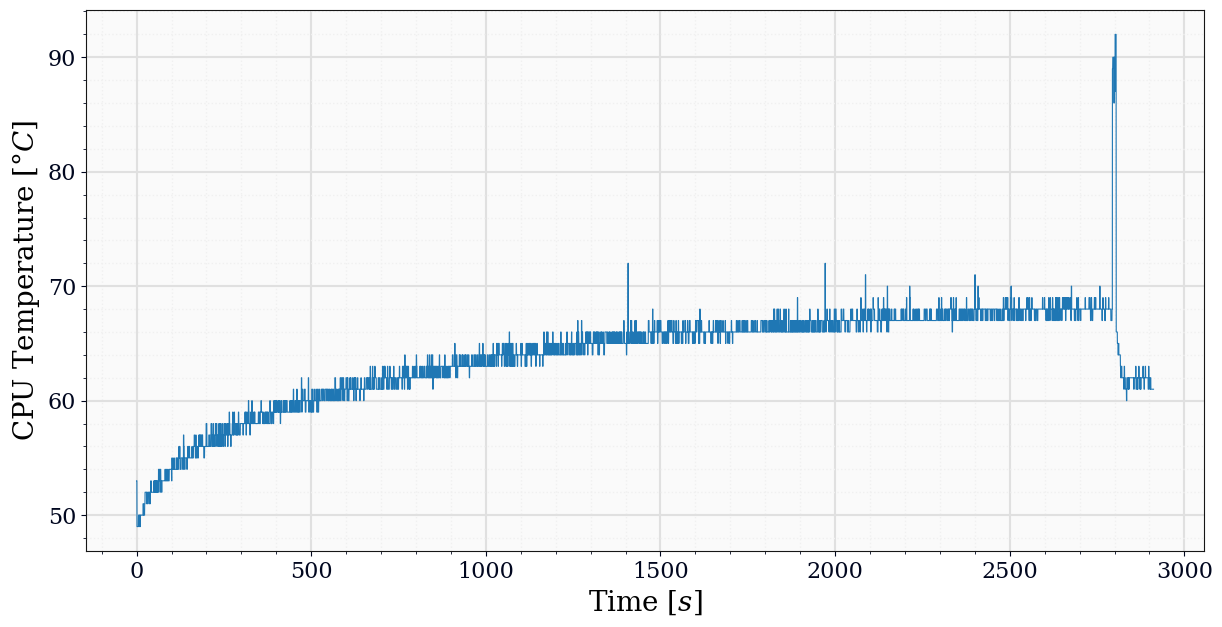

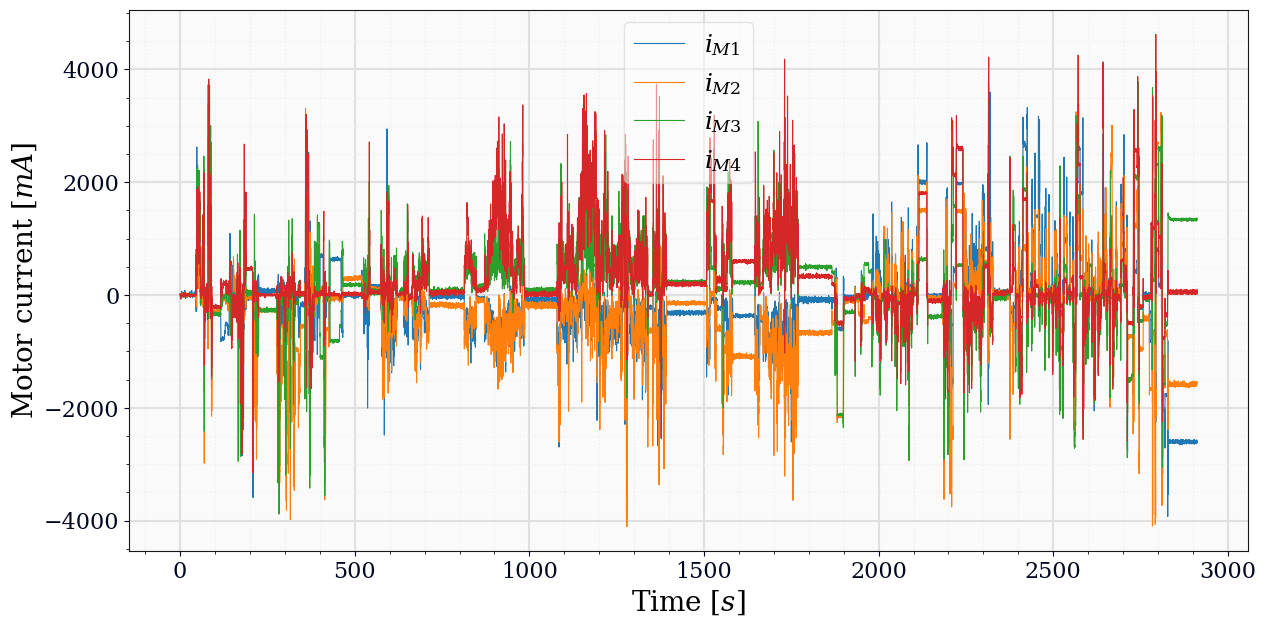

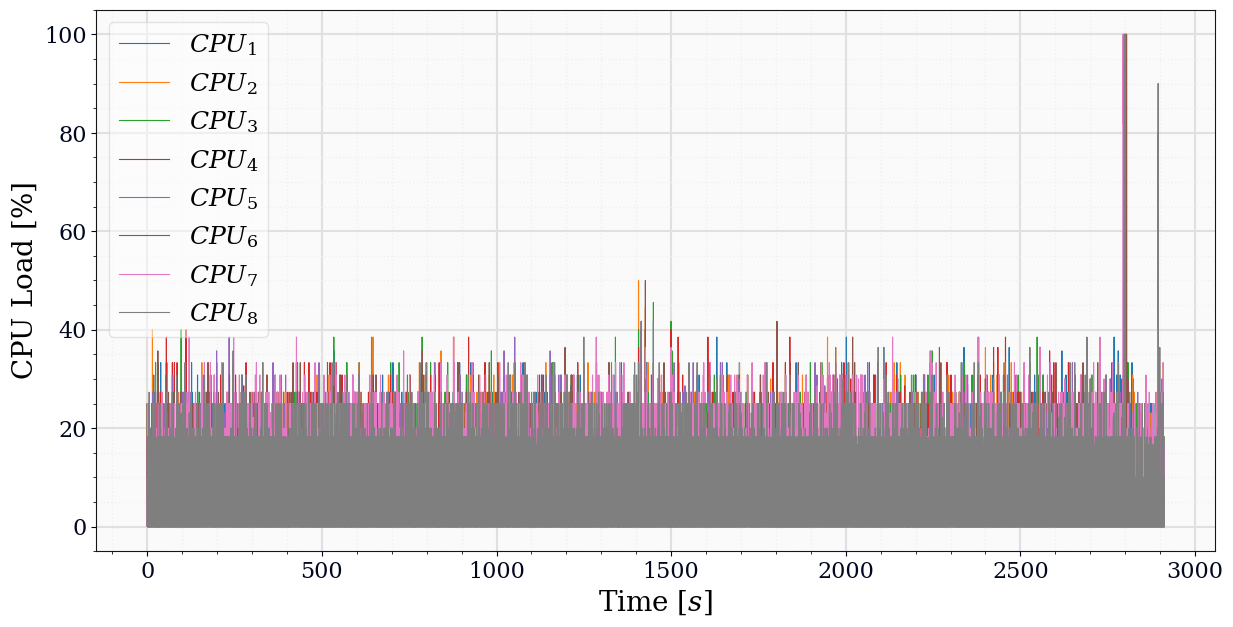

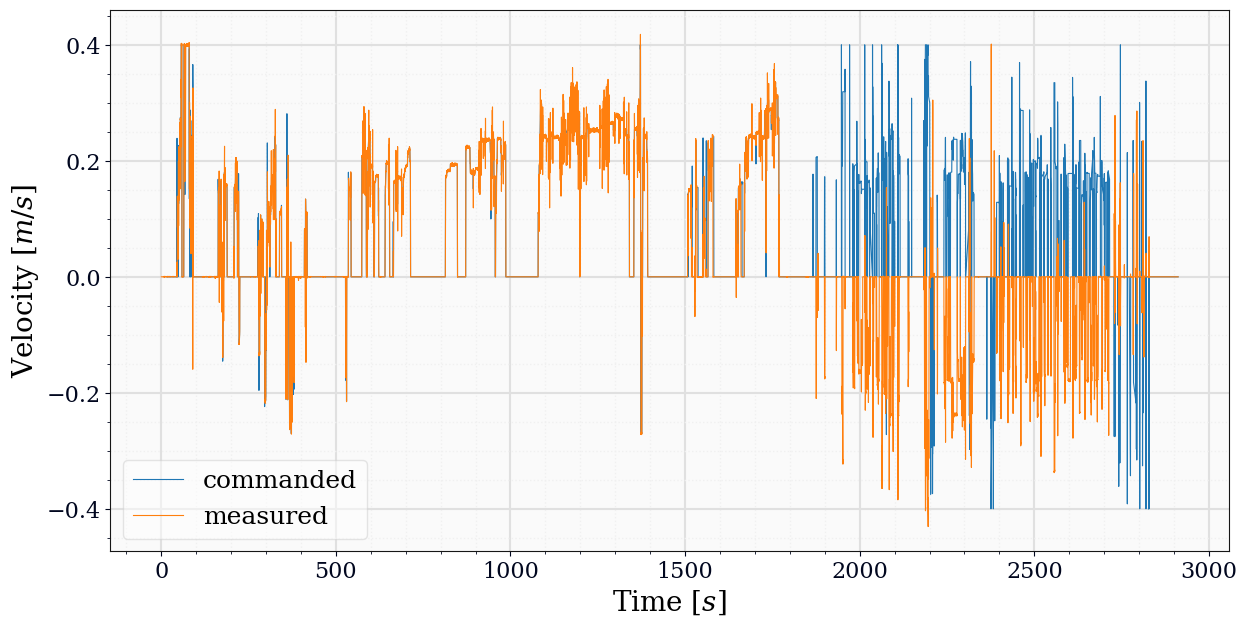

In [4]:
# Cria a variável "telemetria" a partir da bag selecionada acima


# ===================== Desembaraça as mensagens salvas na bag =====================
# Temperatura da CPU
aux1 = b.message_by_topic('/cpu_temp')
aux1 = pd.read_csv(aux1)
aux1 = aux1.rename(columns={'data': 'T_CPU'})
aux1.Time = aux1.Time - b.start_time

# # Corrente instantânea da bateria 1
# aux2 = b.message_by_topic('/espeleo_io/battery_1_signed_status')
# aux2 = pd.read_csv(aux2)
# aux2 = aux2.drop(['layout.dim','layout.data_offset','data_0','data_2'],axis=1)
# aux2 = aux2.rename(columns={'data_1': 'i_B1'})
# aux2.i_B1=-aux2.i_B1
# aux2.Time = aux2.Time - b.start_time

# # Corrente média da bateria 1
# aux3 = b.message_by_topic('/espeleo_io/battery_1_signed_status')
# aux3 = pd.read_csv(aux3)
# aux3 = aux3.drop(['layout.dim','layout.data_offset','data_0','data_1'],axis=1)
# aux3 = aux3.rename(columns={'data_2': 'i_B1_avg'})
# aux3.i_B1_avg=-aux3.i_B1_avg
# aux3.Time = aux3.Time - b.start_time

# # Corrente instantânea da bateria 2
# aux4 = b.message_by_topic('/espeleo_io/battery_2_signed_status')
# aux4 = pd.read_csv(aux4)
# aux4 = aux4.drop(['layout.dim','layout.data_offset','data_0','data_2'],axis=1)
# aux4 = aux4.rename(columns={'data_1': 'i_B2'})
# aux4.i_B2=-aux4.i_B2
# aux4.Time = aux4.Time - b.start_time

# # Corrente média da bateria 2
# aux5 = b.message_by_topic('/espeleo_io/battery_2_signed_status')
# aux5 = pd.read_csv(aux5)
# aux5 = aux5.drop(['layout.dim','layout.data_offset','data_0','data_1'],axis=1)
# aux5 = aux5.rename(columns={'data_2': 'i_B2_avg'})
# aux5.i_B2_avg=-aux5.i_B2_avg
# aux5.Time = aux5.Time - b.start_time

# Corrente no motor 1
aux6 = b.message_by_topic('/device1/get_current_actual_value')
aux6 = pd.read_csv(aux6)
aux6 = aux6.rename(columns={'data': 'i_M1'})
aux6.Time = aux6.Time - b.start_time

# Corrente no motor 2
aux7 = b.message_by_topic('/device3/get_current_actual_value')
aux7 = pd.read_csv(aux7)
aux7 = aux7.rename(columns={'data': 'i_M2'})
aux7.Time = aux7.Time - b.start_time

# Corrente no motor 3
aux8 = b.message_by_topic('/device4/get_current_actual_value')
aux8 = pd.read_csv(aux8)
aux8 = aux8.rename(columns={'data': 'i_M3'})
aux8.Time = aux8.Time - b.start_time

# Corrente no motor 4
aux9 = b.message_by_topic('/device6/get_current_actual_value')
aux9 = pd.read_csv(aux9)
aux9 = aux9.rename(columns={'data': 'i_M4'})
aux9.Time = aux9.Time - b.start_time

# # Intensidade dos LEDs frontais
# aux10 = b.message_by_topic('/espeleo_io/frontLight')
# aux10 = pd.read_csv(aux10)
# aux10 = aux10.drop(['chooseLight'],axis=1)
# aux10 = aux10.rename(columns={'intensityLight': 'LED_F'})
# aux10.Time = aux10.Time - b.start_time

# # Intensidade dos LEDs traseiros
# aux11 = b.message_by_topic('/espeleo_io/backLight')
# aux11 = pd.read_csv(aux11)
# aux11 = aux11.drop(['chooseLight'],axis=1)
# aux11 = aux11.rename(columns={'intensityLight': 'LED_B'})
# aux11.Time = aux11.Time - b.start_time

# Porcentagem de utilizacao da CPU
aux12=b.message_by_topic('/cpu_percent')
aux12=pd.read_csv(aux12)
aux12.rename(columns=lambda col: re.sub(r'^data_(\d+)$', r'CPU_\1', col), inplace=True)
aux12.drop(['layout.dim','layout.data_offset'],axis=1,inplace=True)
aux12.Time = aux12.Time - b.start_time

# Resolve o número de CPUs
NumCPUs=len(aux12.columns)-1    # Se for rodado depois de retirar colunas de layout


aux13 = b.message_by_topic('/cmd_vel')
aux13 = pd.read_csv(aux13)
aux13.drop(['linear.y','linear.z','angular.x','angular.y','angular.z'],axis=1,inplace=True)
aux13 = aux13.rename(columns={'linear.x': 'cmd_vel'})
aux13.Time = aux13.Time - b.start_time

aux14 = b.message_by_topic('/robot_vel')
aux14 = pd.read_csv(aux14)
aux14 = aux14.rename(columns={'linear.x': 'robot_vel'})
aux14.drop(['linear.y','linear.z','angular.x','angular.y','angular.z'],axis=1,inplace=True)
aux14.Time = aux14.Time - b.start_time

# Monta um DataFrame consolidando todas as variáveis
# telemetria=pd.merge_ordered(aux1,aux2,on='Time',how='outer')
# telemetria=pd.merge_ordered(telemetria,aux3,on='Time',how='outer')
# telemetria=pd.merge_ordered(telemetria,aux4,on='Time',how='outer')
# telemetria=pd.merge_ordered(telemetria,aux5,on='Time',how='outer')
telemetria=pd.merge_ordered(aux1,aux6,on='Time',how='outer')
telemetria=pd.merge_ordered(telemetria,aux7,on='Time',how='outer')
telemetria=pd.merge_ordered(telemetria,aux8,on='Time',how='outer')
telemetria=pd.merge_ordered(telemetria,aux9,on='Time',how='outer')
# telemetria=pd.merge_ordered(telemetria,aux10,on='Time',how='outer')
# telemetria=pd.merge_ordered(telemetria,aux11,on='Time',how='outer')
telemetria=pd.merge_ordered(telemetria,aux12,on='Time',how='outer')
telemetria=pd.merge_ordered(telemetria,aux13,on='Time',how='outer')
telemetria=pd.merge_ordered(telemetria,aux14,on='Time',how='outer')
telemetria=telemetria.set_index('Time')


# ========================================== Limpa o DataFrame ==========================================
# Preenche os valores NaN com interpolação linear ou ZOH conforme o que faz mais sentido para cada variável.
telemetria.T_CPU=telemetria.T_CPU.fillna(method='ffill')
# telemetria.i_B1=telemetria.i_B1.interpolate(method='linear')
# telemetria.i_B1_avg=telemetria.i_B1_avg.interpolate(method='linear')
# telemetria.i_B2=telemetria.i_B2.interpolate(method='linear')
# telemetria=telemetria.rename(columns={'i_B2_x': 'i_B2'})
# telemetria.i_B2_avg=telemetria.i_B2_avg.interpolate(method='linear')
telemetria.i_M1=telemetria.i_M1.interpolate(method='linear')
telemetria=telemetria.rename(columns={'i_M1_x': 'i_M1'})
telemetria.i_M2=telemetria.i_M2.interpolate(method='linear')
telemetria=telemetria.rename(columns={'i_M2_x': 'i_M2'})
telemetria.i_M3=telemetria.i_M3.interpolate(method='linear')
telemetria=telemetria.rename(columns={'i_M3_x': 'i_M3'})
telemetria.i_M4=telemetria.i_M4.interpolate(method='linear')
telemetria=telemetria.rename(columns={'i_M4_x': 'i_M4'})
# telemetria.LED_F=telemetria.LED_F.fillna(method='ffill').fillna(0)
# telemetria.LED_F=telemetria.LED_F
# telemetria.LED_B=telemetria.LED_B.fillna(method='ffill').fillna(0)
# telemetria.LED_B=telemetria.LED_B.fillna(0)
for CPU in range(NumCPUs):     telemetria[f'CPU_{CPU}']=telemetria[f'CPU_{CPU}'].interpolate(method='linear')
telemetria.cmd_vel=telemetria.cmd_vel.interpolate(method='linear')
telemetria.robot_vel=telemetria.robot_vel.interpolate(method='linear')
# telemetria=telemetria.dropna()

# Salva em arquivo do excel
telemetria.to_excel('telemetria.xlsx')
# Limpa variáveis desnecessárias
# del aux1, aux2, aux3, aux4, aux5, aux6, aux7, aux8, aux9, aux10, aux11, aux12
del aux1, aux6, aux7, aux8, aux9, aux12, aux13, aux14
gc.collect()

# ===================== Plota a telemetria extraída da bag e a média móvel da temperatura da CPU =====================
fig, ax = bagpy.create_fig(1)
ax=ax[0]
ax.plot('T_CPU',     data = telemetria,       linewidth=0.8)
ax.set_ylabel('CPU Temperature '+r'$[°C]$')
ax.set_xlabel('Time '+r'$[s]$')
ax.set_facecolor('#fafafa')
ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
ax.grid(which='minor', color='#f0f0f0', linewidth=1)
fig.savefig("TelemetryTemperature.svg", format='svg')

# ax[1].plot('i_B1',      data = telemetria,	  label = r'$i_{B1}$',                linewidth=0.8)
# ax[1].plot('i_B2',      data = telemetria,      label = r'$i_{B2}$',                linewidth=0.8)
# ax[1].plot('i_B1_avg',  data = telemetria,      label = r'$\overline{i}_{B1}$',     linewidth=2)
# ax[1].plot('i_B2_avg',  data = telemetria,      label = r'$\overline{i}_{B2}$',     linewidth=2)
# ax[1].set_ylabel('Corrente da bateria '+r'$[mA]$')
fig, ax = bagpy.create_fig(1)
ax=ax[0]
ax.plot('i_M1',      data = telemetria,      label = r'$i_{M1}$',                linewidth=0.8)
ax.plot('i_M2',      data = telemetria,      label = r'$i_{M2}$',                linewidth=0.8)
ax.plot('i_M3',      data = telemetria,      label = r'$i_{M3}$',                linewidth=0.8)
ax.plot('i_M4',      data = telemetria,      label = r'$i_{M4}$',                linewidth=0.8)
ax.set_ylabel('Motor current '+r'$[mA]$')
ax.legend(fontsize=18)
ax.set_xlabel('Time '+r'$[s]$')
ax.set_facecolor('#fafafa')
ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
ax.grid(which='minor', color='#f0f0f0', linewidth=1)
fig.savefig("TelemetryMotors.svg", format='svg')

# ax[3].plot('LED_F',     data = telemetria,      label = r'$LED_{F}$',               linewidth=2, alpha=0.7)
# ax[3].plot('LED_B',     data = telemetria,      label = r'$LED_{B}$',               linewidth=2, alpha=0.7)
# ax[3].set_ylabel('Carga '+r'$[\%]$')
fig, ax = bagpy.create_fig(1)
ax=ax[0]
for CPU in range(NumCPUs):
	# kw = dict(linewidth=0.8) if CPU == 0 else dict(alpha=0.6, linewidth=0, linestyle=None, marker='o', markersize=1)
	kw=dict(linewidth=0.8)
	ax.plot(f'CPU_{CPU}', data = telemetria, label = fr'$CPU_{{{CPU+1}}}$', **kw)
ax.set_ylabel('CPU Load '+r'$[\%]$')
ax.legend(fontsize=18,markerscale=5)
ax.set_xlabel('Time '+r'$[s]$')
ax.set_facecolor('#fafafa')
ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
ax.grid(which='minor', color='#f0f0f0', linewidth=1)
fig.savefig("TelemetryCPU.svg", format='svg')

fig, ax = bagpy.create_fig(1)
ax=ax[0]
ax.plot('cmd_vel',      data = telemetria,      label = 'commanded',                linewidth=0.8)
ax.plot('robot_vel',      data = telemetria,      label = 'measured',                linewidth=0.8)
ax.set_ylabel('Velocity '+r'$[m/s]$')
ax.legend(fontsize=18)
ax.set_xlabel('Time '+r'$[s]$')
ax.set_facecolor('#fafafa')
ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
ax.grid(which='minor', color='#f0f0f0', linewidth=1)
fig.savefig("TelemetryVel.svg", format='svg')

del ax, fig
gc.collect()

In [149]:
#   Parâmetros para configuração do processamento de dados 
Window_temp=10         # Tamanho da janela usada para calcular a média móvel da T_CPU
Window_mot=1           # Tamanho da janela usada para calcular a média móvel das correntes dos motores
NumBuckets=10          # Em quantos buckets dividir a grandeza "dissipação"

max_lag = 4

#   Parâmetros para treinamento do modelo
target=['T_CPU']
features=[
            #'T_CPU',
            #'i_B1','i_B1_avg','i_B2','i_B2_avg',
            #'i_M1','i_M2','i_M3','i_M4',
            'T_CPU_trend',# 'T_CPU_detrend',
            'T_CPU_trend_lag1','T_CPU_trend_lag2','T_CPU_trend_lag3','T_CPU_trend_lag4',
            'CPU_0','CPU_1','CPU_2','CPU_3','CPU_4','CPU_5','CPU_6','CPU_7',
            # 'LED_F', 'LED_B',
            # 'Dissip_B1','Dissip_B2',
            'Dissip_M1','Dissip_M2','Dissip_M3','Dissip_M4',
            'Dissip_M1_lag1','Dissip_M1_lag2','Dissip_M1_lag3','Dissip_M1_lag4',
            'Dissip_M2_lag1','Dissip_M2_lag2','Dissip_M2_lag3','Dissip_M2_lag4',
            'Dissip_M3_lag1','Dissip_M3_lag2','Dissip_M3_lag3','Dissip_M3_lag4',
            'Dissip_M4_lag1','Dissip_M4_lag2','Dissip_M4_lag3','Dissip_M4_lag4',
          ]


# Parâmetros para validação cruzada
NumFolds=5
TamTeste=50000
GapTeste=500
n_estimators=1000

In [150]:
# Processamento de dados


# ======= Cria ou sobreescreve df para receber os cálculos =======
df=telemetria[target]
for f in features:
    if f in telemetria.columns: 
        df=df.merge(telemetria[f],left_index=True,right_index=True)
        


# ===================== Calcula a média móvel da temperatura da CPU =====================
trend=df[target].rolling(Window_temp).sum()/Window_temp                                 # Calcula a média móvel
df=df.merge(trend.rename(columns={'T_CPU':'T_CPU_trend'}),left_index=True, right_index=True)      # Acrescenta ao DataFrame


# Gera o feature "Dissipação" (quadrado da corrente, dividido em buckets conforme o valor)
# para cada corrente medida
# Calcula a "dissipação" devido às correntes
# diss_B1 = (telemetria['i_B1']/1000)**2 
# diss_B2 = (telemetria['i_B2']/1000)**2 
diss_M1 = (telemetria['i_M1']/1000)**2 
diss_M2 = (telemetria['i_M2']/1000)**2
diss_M3 = (telemetria['i_M3']/1000)**2
diss_M4 = (telemetria['i_M4']/1000)**2

# Calcula a média móvel para as dissipações nos motores
diss_M1=diss_M1.rolling(Window_mot).sum()/Window_mot
diss_M2=diss_M2.rolling(Window_mot).sum()/Window_mot
diss_M3=diss_M3.rolling(Window_mot).sum()/Window_mot
diss_M4=diss_M4.rolling(Window_mot).sum()/Window_mot


# Configura os buckets
# amplitude=max(max(diss_B1),max(diss_B2),max(diss_M1),max(diss_M2),max(diss_M3),max(diss_M4))
amplitude=max(max(diss_M1.dropna()),max(diss_M2.dropna()),max(diss_M3.dropna()),max(diss_M4.dropna()))

oom=10**math.floor(math.log10(amplitude))
BucketMax=math.ceil(amplitude/oom)*oom
BucketStep=BucketMax/NumBuckets


# Calcula a dissipação da CPU
if 'Dissip_CPU' in features: 
    diss_CPU=pd.DataFrame(data=telemetria['CPU_0']**2, index=telemetria.index)
    for cc in range(1,NumCPUs):
        for j in range(len(telemetria)):
            diss_CPU.iloc[j]+=telemetria[f'CPU_{cc}'].iloc[j]**2
    diss_CPU=diss_CPU/NumCPUs
    df=df.merge(right=diss_CPU.rename(columns={'CPU_0':'Dissip_CPU'}), right_index=True, left_index=True)


# ================== Calcula feature para baterias e inclui no DataFrame telemetria ==================
# Bateria 1
# df=df.merge(left_index=True, right_index=True, 
#             right=pd.DataFrame(
#                 index=telemetria.index, 
#                 data=np.floor(
#                     diss_B1.values
#                     /BucketStep)*BucketStep, 
#                 columns=['Dissip_B1'])
#             )

# Bateria 2
# df=df.merge(left_index=True, right_index=True, 
#             right=pd.DataFrame(
#                 index=telemetria.index, 
#                 data=np.floor(
#                     diss_B2.values
#                     /BucketStep)*BucketStep, 
#                 columns=['Dissip_B2'])
#             )

# Motor 1
df=df.merge(left_index=True, right_index=True, 
            right=pd.DataFrame(
                index=telemetria.index, 
                data=np.floor(
                    diss_M1.values
                    /BucketStep)*BucketStep, 
                columns=['Dissip_M1'])
            )

# M2
df=df.merge(left_index=True, right_index=True, 
            right=pd.DataFrame(
                index=telemetria.index, 
                data=np.floor(
                    diss_M2.values
                    /BucketStep)*BucketStep, 
                columns=['Dissip_M2'])
            )

# M3
df=df.merge(left_index=True, right_index=True, 
            right=pd.DataFrame(
                index=telemetria.index, 
                data=np.floor(
                    diss_M3.values
                    /BucketStep)*BucketStep, 
                columns=['Dissip_M3'])
            )

# M4
df=df.merge(left_index=True, right_index=True, 
            right=pd.DataFrame(
                index=telemetria.index, 
                data=np.floor(
                    diss_M4.values
                    /BucketStep)*BucketStep, 
                columns=['Dissip_M4'])
            )


df=df.dropna()

if False:   # Plotar as variáveis dissipação individuais?   
    fig, ax = plt.subplots(figsize=(15,5))
    diss_B1.plot(ax=ax,lw=0.8)
    diss_B2.plot(ax=ax,lw=0.8)
    diss_M1.plot(ax=ax,lw=0.8)
    diss_M2.plot(ax=ax,lw=0.8)
    diss_M3.plot(ax=ax,lw=0.8)
    diss_M4.plot(ax=ax,lw=0.8)
    ax.set_facecolor('#fafafa')
    ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
    ax.grid(which='minor', color='#f0f0f0', linewidth=1)
    del fig, ax


# ================== Cria lag feature e inclui no df ==================
df['T_CPU_lag']=df['T_CPU_trend'].shift(math.floor(-Window_temp/2))


# =============== Cria a feature detrend e inclui no df ===============
df['T_CPU_detrend']=telemetria['T_CPU']-df['T_CPU_trend']


for i in range(1, max_lag + 1):
    df[f'T_CPU_trend_lag{i}'] = df['T_CPU_trend'].shift(i)
    df[f'Dissip_M1_lag{i}'] = df['Dissip_M1'].shift(i)
    df[f'Dissip_M2_lag{i}'] = df['Dissip_M2'].shift(i)
    df[f'Dissip_M3_lag{i}'] = df['Dissip_M3'].shift(i)
    df[f'Dissip_M4_lag{i}'] = df['Dissip_M4'].shift(i)

    
df = df.dropna()

# Limpa variáveis auxiliares
# del diss_B1, diss_B2, diss_M1, diss_M2, diss_M3, diss_M4
del diss_M1, diss_M2, diss_M3, diss_M4
del amplitude, BucketMax, BucketStep, oom
gc.collect()

34726

In [144]:
# Copia o pico de temperatura e o trecho de CPU correspondente, e repete NumCopias vezes
NumCopias=10
def closestn(array,num,n):
    if isinstance(array,pd.Series): array = array.to_numpy()
    if isinstance(array[0],float): delta = np.ones(n, dtype=float) * np.finfo(float).max
    elif isinstance(array[0],int): delta = np.ones(n, dtype=int) * np.iinfo(int).max
    else: raise Exception('Data type not supported')
    
    NumElem=len(array)
    
    ind=[0]*n
    for i in range(NumElem):
        aux=abs(array[i]-num)
        for r in range(n):
            if delta[r]>aux: 
                for k in range(r,n-1):
                    delta[-k-1]=delta[-k-2]
                    ind[-k-1]=ind[-k-2]
                delta[r]=aux
                ind[r]=i
                break
    z=sorted(zip(array[ind]+0.0,ind,delta))
    y,x,delta=zip(*z)
    if isinstance(array[0], float):
        y = list(map(float, y))  # Convert y elements back to float
        delta = list(map(float, delta))  # Convert y elements back to float
    elif isinstance(array[0], int):
        y = list(map(int, y))  # Convert y elements back to float
        delta = list(map(int, delta))  # Convert y elements back to float
    return list(x),y,delta
closestn(df.index,2804.659727,1)
UltimaTempAlta=closestn(df.index,2804.659727,1)[0][0]-1
aux=df.iloc[0:UltimaTempAlta]
i_copy=closestn(aux.index,2500,1)[0][0]-1
copy=aux.iloc[i_copy:len(aux)]
shift_time=copy.index[-1]-copy.index[0]
for i in range(NumCopias):
    copy.index=copy.index+shift_time
    aux = pd.concat([aux, copy], axis=0, ignore_index=False)

df=aux

Score across folds 2.3345
Fold scores:[np.float64(2.6178934995468173), np.float64(2.9421421462831376), np.float64(2.229772028025859), np.float64(1.8999739971389284), np.float64(1.9825070217243932)]


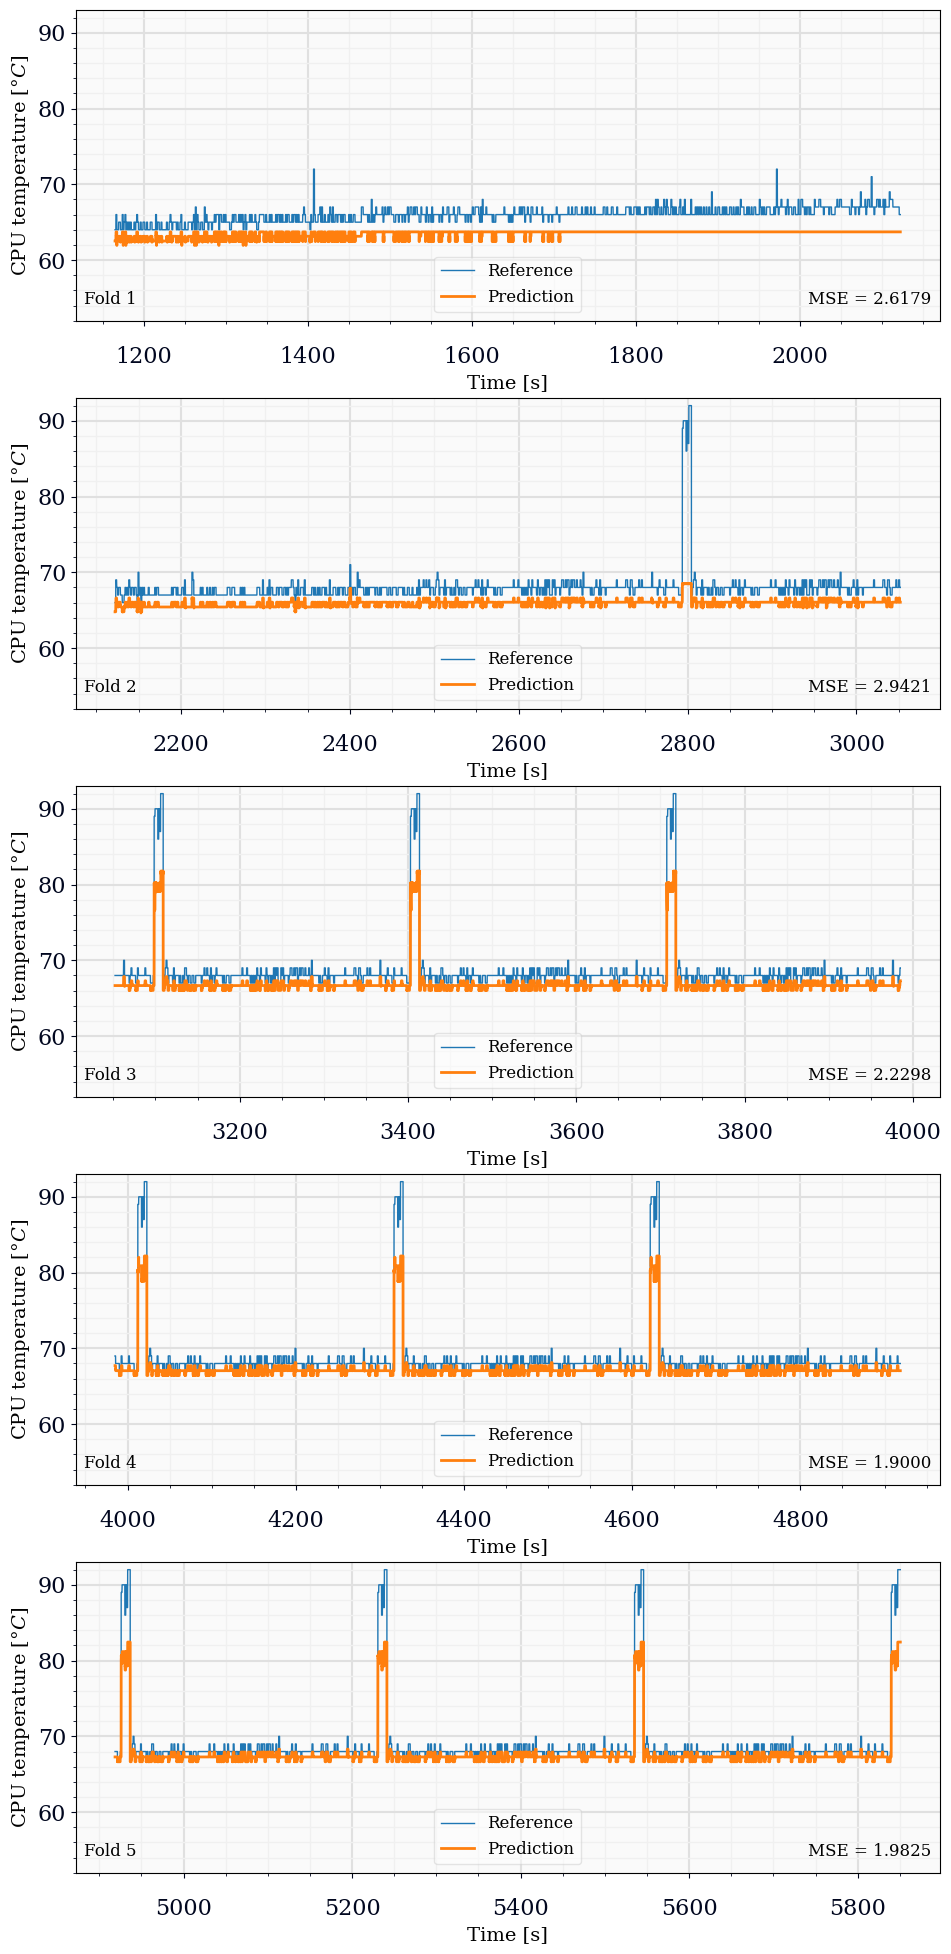

In [ ]:
# Treina o modelo XGBoost e faz predições
import xgboost as xgb
from sklearn.metrics import mean_squared_error

tss = TimeSeriesSplit(n_splits=NumFolds, test_size=TamTeste, gap=GapTeste)
fig, ax = plt.subplots(nrows=NumFolds,ncols=1,figsize=(10,4*NumFolds))

fold=0
preds=[]
scores=[]
fold_dfs = []
for train_idx, val_idx in tss.split(df):
	Train=df.iloc[train_idx]
	Test=df.iloc[val_idx]
	
	X_Train=Train[features]
	Y_Train=Train[target]
	X_Test=Test[features]
	Y_Test=Test[target]
	
	
	reg= xgb.XGBRegressor(n_estimators=n_estimators,early_stopping_rounds=20, learning_rate=0.001)
	reg.fit(X_Train,Y_Train,
		eval_set=[(X_Train,Y_Train), (X_Test,Y_Test)],
		# verbose=300
		verbose=False
	)
	
	Y_Pred=reg.predict(X_Test)
	preds.append(Y_Pred)
	
	fold_df = pd.DataFrame({
		f'ref_fold{fold+1}': Y_Test.values.flatten(),
		f'pred_fold{fold+1}': Y_Pred.flatten()
	}, index=Y_Test.index)
	fold_dfs.append(fold_df)        
	score=np.sqrt(mean_squared_error(Y_Test,Y_Pred))
	scores.append(score)
	ax[fold].plot('T_CPU', data=Y_Test, lw=1, label='Reference')
	ax[fold].plot(Y_Test.index,Y_Pred, lw=2, label='Prediction')
	ax[fold].set_facecolor('#fafafa')
	ax[fold].grid(which='major', color='#e0e0e0', linewidth=1.5)
	ax[fold].grid(which='minor', color='#f0f0f0', linewidth=1)
	ax[fold].set_ylabel('CPU temperature '+r'$[°C]$', fontsize=14)
	ax[fold].set_xlabel('Time [s]', fontsize=14)
	ax[fold].annotate(f'Fold {fold+1}', 
		xy=(0.01,0.04), xycoords='axes fraction', fontsize=12, horizontalalignment='left', verticalalignment='bottom')
	ax[fold].annotate(f'MSE = {score:0.4f}',
		xy=(0.99,0.04), xycoords='axes fraction', fontsize=12, horizontalalignment='right', verticalalignment='bottom')
	ax[fold].legend(loc='lower center', fontsize=12)
	
	fold+=1
	
Y_max=max(max(telemetria['T_CPU']),max(np.concatenate(preds).ravel()))
Y_min=min(min(telemetria['T_CPU']),min(np.concatenate(preds).ravel()))
oom=10**(math.floor(math.log10(Y_max))-1)
for a in ax:
        a.set_ylim([math.floor(Y_min/oom)*oom+3,math.ceil(Y_max/oom)*oom+1])
        
print(f'Score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')
plt.tight_layout(h_pad=0.2)

plt.gcf().savefig("Predictions.svg",bbox_inches='tight')

(2760.0, 2840.0)

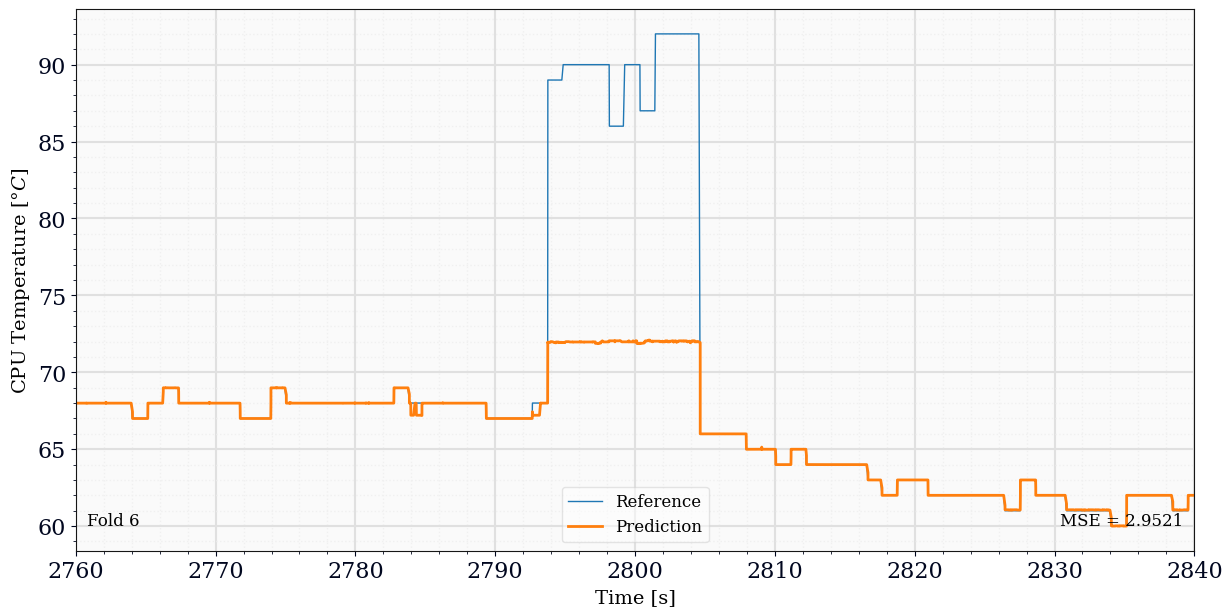

In [42]:
# Plota gráficos com zoom em instantes de das predições
x=[2760,2840]

fig, ax = bagpy.create_fig(1)
ax=ax[0]
ax.plot('ref_fold5', data=fold_dfs[-1], lw=1, label='Reference')
ax.plot('pred_fold5', data=fold_dfs[-1], lw=2, label='Prediction')
ax.set_facecolor('#fafafa')
ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
ax.grid(which='minor', color='#f0f0f0', linewidth=1)
ax.set_ylabel('CPU Temperature '+r'$[°C]$', fontsize=14)
ax.set_xlabel('Time [s]', fontsize=14)
ax.annotate(f'Fold {fold+1}', 
		xy=(0.01,0.04), xycoords='axes fraction', fontsize=12, horizontalalignment='left', verticalalignment='bottom')
ax.annotate(f'MSE = {score:0.4f}',
		xy=(0.99,0.04), xycoords='axes fraction', fontsize=12, horizontalalignment='right', verticalalignment='bottom')
ax.legend(loc='lower center', fontsize=12)
ax.set_xlim(x)



C:\Users\leoki\AppData\Local\Temp\ipykernel_18908\322186988.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''])


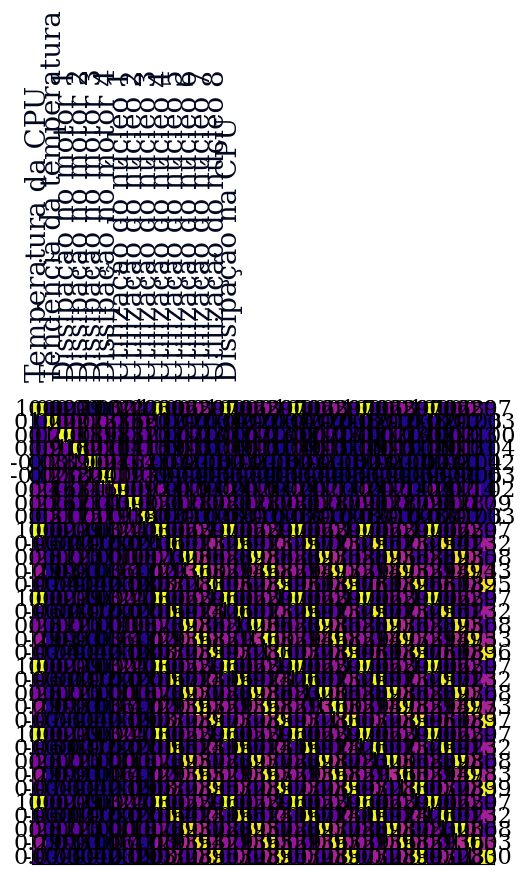

In [129]:
# Plota a matriz de covariância
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pylab

labels=[
    'Temperatura da CPU',
    # 'Carga no LED frontal',
    # 'Carga no LED traseiro',
    'Tendência da temperatura',
    # 'Dissipação na bateria 1',
    # 'Dissipação na bateria 2',
    'Dissipação no motor 1',
    'Dissipação no motor 2',
    'Dissipação no motor 3',
    'Dissipação no motor 4',
    'Utilização do núcleo 1',
    'Utilização do núcleo 2',
    'Utilização do núcleo 3',
    'Utilização do núcleo 4',
    'Utilização do núcleo 5',
    'Utilização do núcleo 6',
    'Utilização do núcleo 7',
    'Utilização do núcleo 8',
    'Dissipação na CPU',
]
mat=df.drop(columns={'T_CPU_lag','T_CPU_detrend'}).corr()

pylab.rcParams['xtick.major.pad']='15'
ax=plt.figure().add_subplot(111)
im=ax.matshow(mat,cmap=plt.colormaps['plasma'])
N=len(mat.columns)
for cc in range(N):
    for j in range(N):
        Px=str("{n:.2f}".format(n=mat.iloc[[cc],[j]].values[0][0]))
        ax.text(cc, j, Px, va='center', ha='center',fontsize=16)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels,rotation='vertical',fontsize=20)
ax.set_yticklabels([''])
ax.tick_params(axis=u'both', which=u'both',length=0)
# divider = make_axes_locatable(ax)
# cax = divider.append_axes("right", size="5%", pad=0.5)   
# plt.colorbar(im, cax=cax)
plt.gcf().savefig("CovMatrix.svg",bbox_inches='tight')


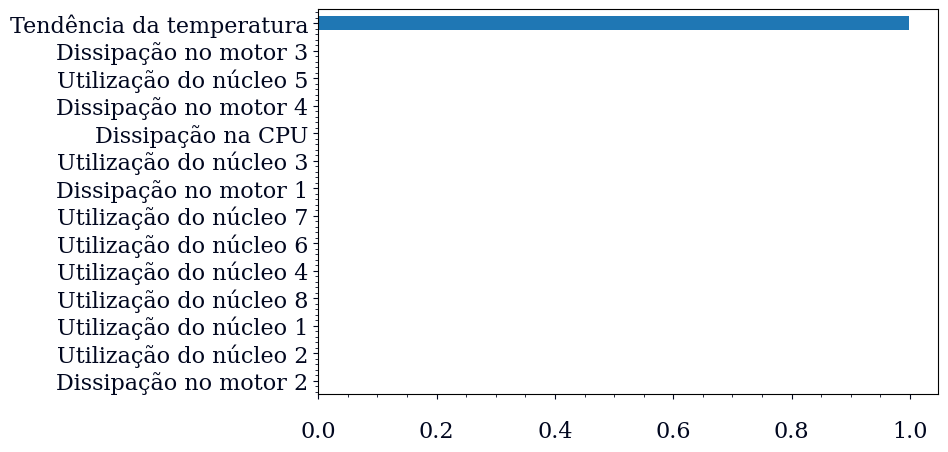

In [32]:
# Plota as importâncias relativas de cada feature
dict={
    'T_CPU_trend':'Tendência da temperatura',
    'LED_F':'Carga no LED frontal',
    'LED_B':'Carga no LED traseiro',
    'Dissip_B1':'Dissipação na batteria 1',
    'Dissip_B2':'Dissipação na batteria 2',
    'Dissip_M1':'Dissipação no motor 1',
    'Dissip_M2':'Dissipação no motor 2',
    'Dissip_M3':'Dissipação no motor 3',
    'Dissip_M4':'Dissipação no motor 4',
    'Dissip_CPU':'Dissipação na CPU',
    'CPU_0':'Utilização do núcleo 1',
    'CPU_1':'Utilização do núcleo 2',
    'CPU_2':'Utilização do núcleo 3',
    'CPU_3':'Utilização do núcleo 4',
    'CPU_4':'Utilização do núcleo 5',
    'CPU_5':'Utilização do núcleo 6',
    'CPU_6':'Utilização do núcleo 7',
    'CPU_7':'Utilização do núcleo 8'
}
fi=pd.DataFrame(index=reg.feature_names_in_, data=reg.feature_importances_, columns=['importance'])
fi=fi.sort_values('importance')
fi=fi.rename(index=dict)
fi.plot(kind='barh',figsize=(8,5))
plt.gca().get_legend().remove()
plt.gcf().savefig("ImportancePlot.svg",bbox_inches='tight')

C:\Users\leoki\AppData\Local\Temp\ipykernel_18908\673372636.py:35: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[0].add_patch(ptc.Rectangle(xy=[Px,ymin],width=-MovingAverageWindow,height=5,


[]

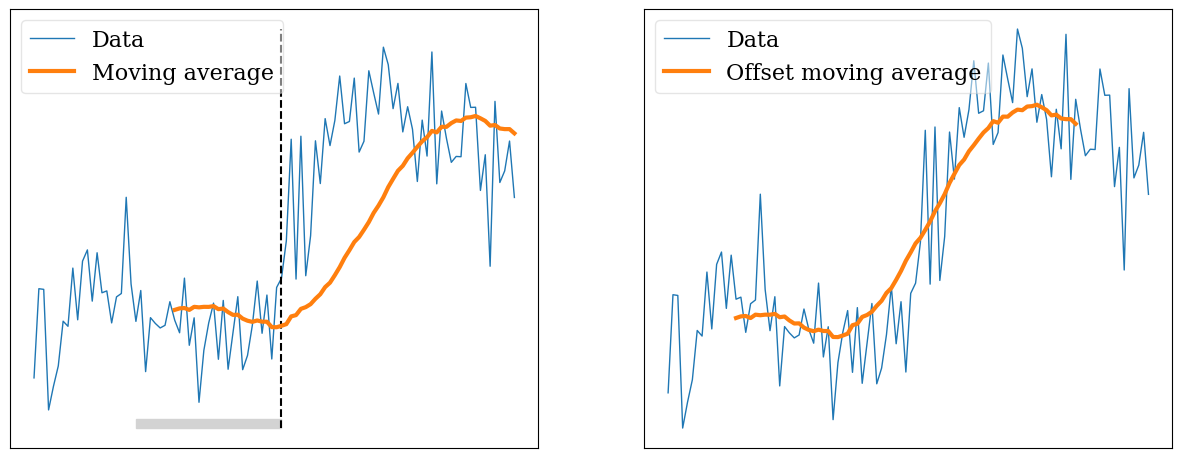

In [217]:
# Plota um gráfico ilustrativo do procedimento de cálculo do feature T_CPU_trend
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as ptc
import random
import math
Layer1Size=10
EscalaX=10
EscalaY=10
PreSmoothWindow=20
MovingAverageWindow=30
fontsize=16
lw_data=1
lw_ma=3

# Layer 1: Define a um vetor base manualmente. Dita a forma aproximada
x1=np.array(range(Layer1Size+2))*EscalaX
y1=np.array([0,0.08618527251172858,0.29276664037142175,0.17339907077578998,0.3148968679197107,0.2636046903087258,0.3962135971001429,0.4595127291716007,0.759708333177639,0.4605307631477288,0.5453521650684118,0.5453521650684118])
y1=y1+np.random.normal(scale=0.3,size=y1.shape)
y1=y1*EscalaY
x=np.array(range(max(x1)+1))
y=np.interp(x,x1,y1)
y=np.convolve(y, np.ones(PreSmoothWindow), mode='same')

# Layer 2: Acrescenta ruído de alta frequência
x=x[0:Layer1Size*EscalaX]
y=y[0:Layer1Size*EscalaX]
y=y+np.random.normal(scale=20,size=y.shape)

# Raw data
Px=math.floor(0.75*(max(x)-MovingAverageWindow))
fig, ax = plt.subplots(1,2,figsize=(15,5.7))
ax[0].plot(x,y,lw=1,label='Data')
ymin, ymax = np.array(ax[0].get_ylim())
ax[0].add_patch(ptc.Rectangle(xy=[Px,ymin],width=-MovingAverageWindow,height=5,
                           color='lightgray',edgecolor='black',lw=lw_data))
ax[0].plot([Px,Px],[ymin, ymax],ls='--',color='black')

# Moving average
MA=np.convolve(y, np.ones(MovingAverageWindow)/MovingAverageWindow, mode='valid')
ax[0].plot(x[MovingAverageWindow-1:x.size],MA,label='Moving average', lw=lw_ma)
ax[0].legend(fontsize=fontsize)
ax[0].set_xticks([])
ax[0].set_yticks([])

offset=math.floor(MovingAverageWindow/2)
ax[1].plot(x,y,lw=lw_data,label='Data')
ax[1].plot(x[MovingAverageWindow-1-offset:x.size-offset],MA,label='Offset moving average', lw=lw_ma)
ax[1].legend(fontsize=fontsize)
ax[1].set_xticks([])
ax[1].set_yticks([])



Text(0.5, 0, 'Dissipation [A²]')

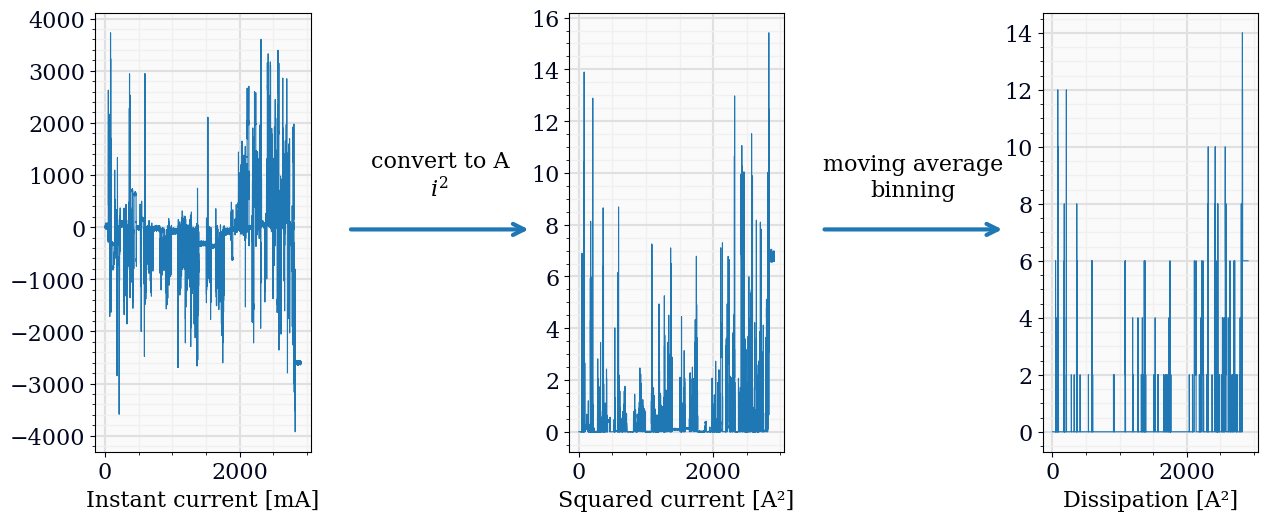

In [225]:
# Plota gráficos ilustrativos do procedimento de cálculo do feature Dissipação
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
fig, ax = plt.subplots(1,3,figsize=(15,5.7))
fig.subplots_adjust(wspace=1.2)
fontsize=16
def plots(data,aa):
	ax[aa].plot(data,linewidth=0.8)
	# ax[aa].set_xticklabels([])
	# ax[aa].set_yticklabels([])
	ax[aa].set_facecolor('#fafafa')
	ax[aa].grid(which='major', color='#e0e0e0', linewidth=1.5)
	ax[aa].grid(which='minor', color='#f0f0f0', linewidth=1)
def desenhaseta(aa_esq, aa_dir, text=''):
	x_esq = ax[aa_esq].get_position().x1
	x_dir = ax[aa_dir].get_position().x0
	margin = 0.025
	arrow = FancyArrowPatch(
		(x_esq+margin, 0.5), (x_dir-margin, 0.5),  # xytext, xy
		transform=fig.transFigure,
		arrowstyle='->',
		mutation_scale=20,
		lw=3, color='#1f77b4'

	)
	fig.add_artist(arrow)
	fig.text((x_esq + x_dir)/2, 0.55, text, ha='center', va='bottom', fontsize=fontsize)

data=telemetria['i_M1']
plots(data,0)
ax[0].set_xlabel('Instant current [mA]', fontsize=fontsize)

desenhaseta(0,1,'convert to A\n'+r'$i^2$')

data_2 = (data/1000)**2
plots(data_2,1)
ax[1].set_xlabel('Squared current [A²]', fontsize=fontsize)

desenhaseta(1,2,'moving average\n'+'binning')

def binning(data,Window,NumBuckets):
	data=data.rolling(Window).sum()/Window
	amplitude=max(data.dropna())
	oom=10**math.floor(math.log10(amplitude))
	BucketMax=math.ceil(amplitude/oom)*oom
	BucketStep=BucketMax/NumBuckets
	data=pd.Series(data=np.floor(data.values/BucketStep)*BucketStep, index=data.index)
	return data
data_3=binning(data_2,Window=3,NumBuckets=10)
plots(data_3,2)
ax[2].set_xlabel('Dissipation [A²]', fontsize=fontsize)




C:\Users\leoki\AppData\Local\Temp\ipykernel_21784\2532223018.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend(fontsize=18)


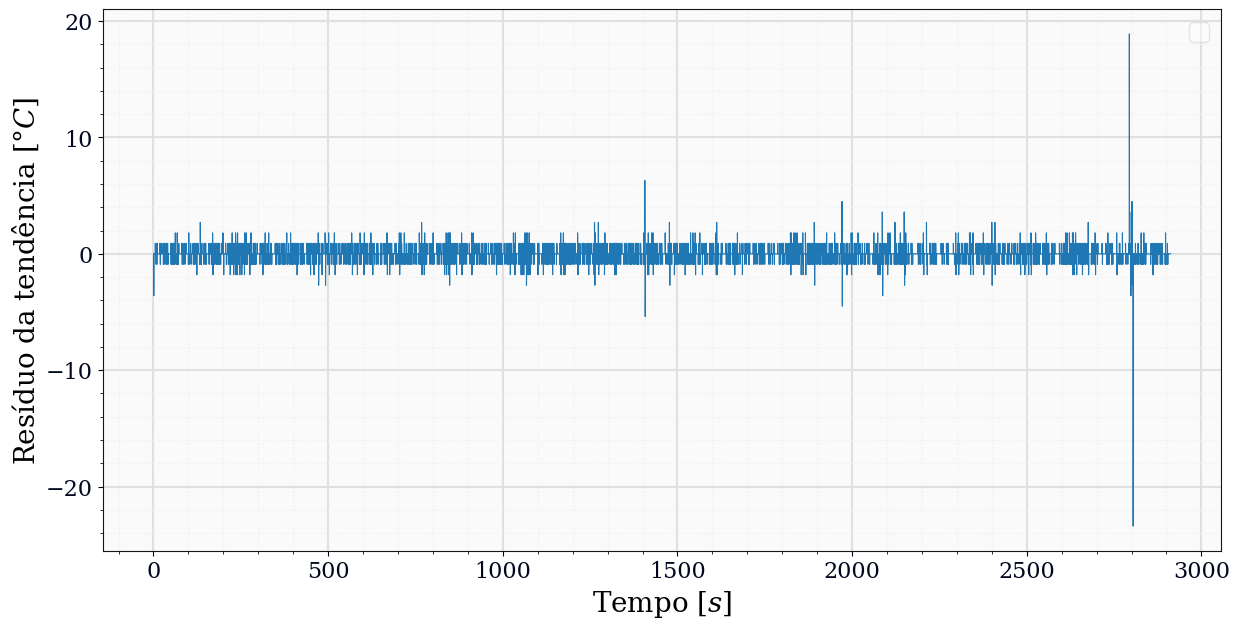

In [15]:
# Plota um gráfico da série temperatura x tempo do resíduo do detrend de T_CPU
fig, ax = bagpy.create_fig(1)
ax[0].plot('T_CPU_detrend',     data = df,      label='',       linewidth=0.8)
ax[0].set_ylabel('Resíduo da tendência '+r'$[°C]$')
for axis in ax:
    axis.legend(fontsize=18)
    axis.set_xlabel('Tempo '+r'$[s]$')
    axis.set_facecolor('#fafafa')
    axis.grid(which='major', color='#e0e0e0', linewidth=1.5)
    axis.grid(which='minor', color='#f0f0f0', linewidth=1)

plt.savefig("TempDetrend.svg",bbox_inches='tight')
plt.show()


In [ ]:
diss_CPU=pd.DataFrame(data=telemetria['CPU_0']**2, index=telemetria.index)
for cc in range(1,NumCPUs):
    for j in range(len(telemetria)):
        diss_CPU.iloc[j]+=telemetria[f'CPU_{cc}'].iloc[j]**2
diss_CPU=diss_CPU/NumCPUs

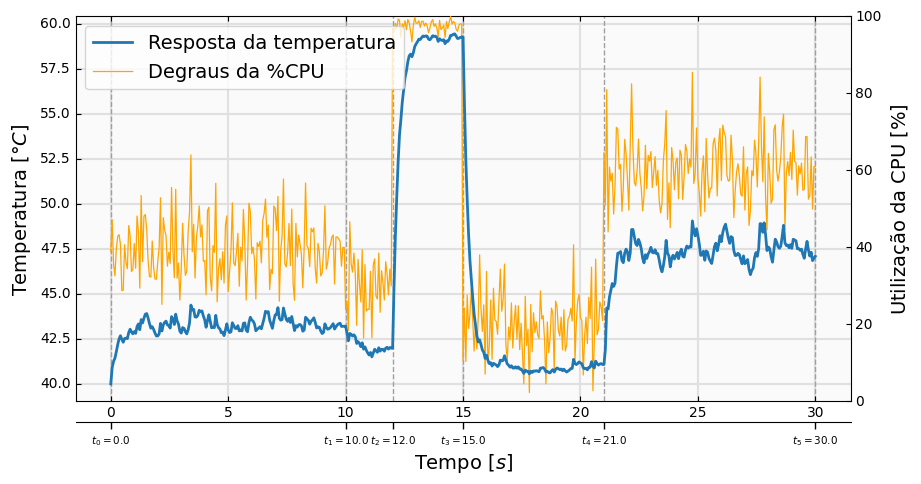

In [1]:
# Plota um gráfico ilustrativo dos trechos de tempo contendo degraus distintos da %CPU e resposta da temperatura
import numpy as np
import pandas as pd

def frange(start,stop,**kwargs):
	opcoes={'step','num'}
	arg = opcoes.intersection(kwargs.keys())
	if len(arg) != 1:
		raise ValueError("Exatamente um dos argumentos 'step' ou 'num' deve ser passado.")
		
	from math import floor, log10
	if stop<start:
		aux=stop
		stop=start
		start=aux

	arg=arg.pop()
	match arg:
		case 'step':
			step = kwargs['step']

			# Calcula a ordem de grandeza para os cálculos
			gr=10**floor(log10(step))
			# Converte os argumentos para números inteiros
			iStart=start/gr
			iStep=step/gr
			iStop=stop/gr

			# Constrói o vetor
			NumElem=floor((iStop-iStart)/iStep)+1
			array=np.zeros(NumElem)
			num=iStart
			for i in range(NumElem):
				array[i]=num*gr
				num+=iStep

			return array
		case 'num':
			num = kwargs['num'] - 1
			delta = (stop-start)/num
			
			array = start+np.array(range(num+1))*delta
			return array
def GeraVetorTempo(t, tol, MinStep, MinPontos, MaxPontos):
	"""
	Para o intervalo [min(t), max(t)], tenta encontrar um vetor de tempos com número de pontos
	variando de min_points até max_points que satisfaça:
		1. Um passo constante, com valor >= min_step.
		2. Cada valor em t apareça no vetor (dentro de tol * max(1, |ti|)).
	
	Se encontrado, 'snap' os valores para que sejam exatamente t; caso contrário, levanta um erro.
	
	Parâmetros:
		- t: lista ou array de números (em ordem crescente) que devem aparecer no vetor final.
		- min_step: valor mínimo permitido para o passo entre os pontos.
		- tol: tolerância para considerar que um valor gerado é igual a um valor em t.
		- min_points: número mínimo de pontos a tentar.
		- max_points: número máximo de pontos permitidos no vetor.
	"""
	# Bloco de validação dos argumentos
	if not isinstance(t, (list, tuple, np.ndarray)):
		raise ValueError("t deve ser uma lista, tupla ou numpy array.")
	if len(t) == 0:
		raise ValueError("t não pode ser vazio.")
	# Verifica se todos os elementos de t são numéricos
	for ti in t:
		if not isinstance(ti, (int, float)):
			raise ValueError("Todos os elementos em t devem ser números.")
	# Verifica se os valores de t estão em ordem crescente
	if any(t[i] > t[i+1] for i in range(len(t)-1)):
		raise ValueError("Os valores em t devem estar em ordem crescente.")
	
	if not (isinstance(MinStep, (int, float)) and MinStep > 0):
		raise ValueError("min_step deve ser um número positivo.")
	if not (isinstance(tol, (int, float)) and tol >= 0):
		raise ValueError("tol deve ser um número não negativo.")
	if not (isinstance(MinPontos, int) and MinPontos > 0):
		raise ValueError("min_points deve ser um inteiro positivo.")
	if not (isinstance(MaxPontos, int) and MaxPontos >= MinPontos):
		raise ValueError("max_points deve ser um inteiro maior ou igual a min_points.")
	if MinPontos < len(t):
		raise ValueError("min_points deve ser pelo menos o número de valores em t.")
	
	start = min(t)
	stop = max(t)
	if (stop - start) / (MinPontos - 1) < MinStep:
		raise ValueError("Parâmetros conflitantes: usando min_points pontos, o step resultante é menor que min_step.")    # Fim da validação dos argumentos

	found = False
	candidate_time_vec = None

	for n in range(MinPontos, MaxPontos + 1):
		# O passo candidato, se usarmos n pontos, seria:
		candidate_step = (stop - start) / (n - 1)
		if candidate_step < MinStep:
			# Se o step resultante for menor que o mínimo, esse candidato é inválido
			continue
		# Gera o vetor usando a opção 'num' de frange (garante exatamente n pontos)
		time_vec = frange(start, stop, num=n)
		# Verifica se cada valor em t está presente (dentro da tolerância)
		all_found = True
		for ti in t:
			if np.abs(time_vec - ti).min() > tol * max(1, abs(ti)):
				all_found = False
				break
		if all_found:
			# "Snap": força os valores que estão dentro da tolerância a serem exatamente t
			candidate_time_vec = time_vec.copy()
			for ti in t:
				idx = np.argmin(np.abs(candidate_time_vec - ti))
				if np.abs(candidate_time_vec[idx] - ti) <= tol * max(1, abs(ti)):
					candidate_time_vec[idx] = ti
			found = True
			break

	if not found:
		raise ValueError(
			f"Não foi possível encontrar um vetor de tempos que inclua todos os valores de t (dentro da tolerância {tol}) "
			f"usando entre {MinPontos} e {MaxPontos} pontos e com step >= {MinStep}."
		)
	return candidate_time_vec
def GeraDF(t,CPU,TempInicial=0,ParamsVetorTempo=None):
	# Gera um DataFrame que contém os dados listados
	if ParamsVetorTempo is None:
		ParamsVetorTempo = {'min_step': 0.1, 'tol': 1e-8, 'min_points': 50, 'max_points': 200}
	
	aux=GeraVetorTempo(t, **ParamsVetorTempo)
	df=pd.DataFrame(data={'t':aux,
						'CPU':np.zeros(len(aux)),
						'Temp':np.ones(len(aux))*TempInicial})

	# Alimenta valores do vetor CPU em df, nas posições especificadas em t
	ind = df.loc[df['t'].isin(t)].index[:len(CPU)]
	df.loc[ind, 'CPU'] = CPU[:len(ind)]

	# Preenche valores de df
	t_stop = t[-2]  # Penúltimo valor de t

	last_value = None
	for i in reversed(df.index):  # Percorre de trás para frente
		if i in ind:
			last_value = df.at[i, 'CPU']  # Atualiza o último valor encontrado
		elif last_value is not None and df.at[i, 't'] > t_stop:
			df.at[i, 'CPU'] = last_value  # Replica o valor
	last_value = None
	for i in df.index:  # Percorre do início ao fim
		if i in ind:
			last_value = df.at[i, 'CPU']  # Atualiza o último valor encontrado
		elif last_value is not None and df.at[i, 't'] <= t_stop:
			df.at[i, 'CPU'] = last_value  # Replica o valor

	df['t_mod'] = df['t']  # Cria uma nova coluna para armazenar o t ajustado
	pt_idx = 0  # Índice para percorrer o vetor Pt
	for i in range(len(df)):
		while pt_idx < len(Pt) - 1 and df.loc[i, 't'] >= Pt[pt_idx + 1]:  
			pt_idx += 1  # Atualiza o índice para o próximo intervalo
		df.loc[i, 't_mod'] = df.loc[i, 't'] - Pt[pt_idx]  # Ajusta t conforme Pt
	df.iloc[-1,-1]=df.iloc[-2,-1]+(df.iloc[-2,-1]-df.iloc[-3,-1])
	df=df.rename(columns={'t':'Timestamp'})
	df=df.set_index('Timestamp')
	df=df.rename(columns={'t_mod':'t'})
	return df
def AdicionaRuido(df,t,col,scale=1):
	ruido=np.random.normal(scale=scale, size=df[col].shape)
	col=df.columns.get_loc(col)
	for i in range(1, len(t)):  # Começamos de 1 para termos um intervalo de t[i-1] a t[i]
		start = df.index.get_loc(t[i-1])  # Índice do início do trecho
		stop = df.index.get_loc(t[i])-1  # Índice do final do trecho
		c = df.iloc[start:stop, col]
		r = ruido[start:stop]

		val = c + r
		
		val_max=max(val)
		if val_max > 1:
			idmax = val.tolist().index(val_max)
			fator_correcao = (1 - c.iloc[idmax]) / r[idmax]
		else: fator_correcao = 1
			# Aplicar o fator de correção no ruído do trecho
		df.iloc[start:stop, col] = df.iloc[start:stop, col] + r * fator_correcao
		df.iloc[start:stop, col] = df.iloc[start:stop, col].clip(lower=0)
def Simulacao(KCPU=4,KTemp=0.1,TauCPU=0.1,TauTemp=0.05):
	from math import exp
	idx=df.columns.get_loc('CPU')
	idy=df.columns.get_loc('Temp')
	idt=df.columns.get_loc('t')

	TempAmb=df.iloc[0,idy]
	DeltaT=df.index[1]-df.index[0]
	for i in range(1,len(df)):
		TempPrev=df.iloc[i-1,idy]
		t=df.iloc[i,idt]
		CPU=df.iloc[i,idx]
		DeltaTemp=TempPrev-TempAmb
		
		TempNext=TempPrev+KCPU*(CPU**2)*(1-exp(-t/TauCPU/DeltaT))-KTemp*(DeltaTemp)*(1-exp(-t/TauTemp/DeltaT))
		# df.iloc[i,idy]=Temp+(KCPU*exp(CPU)-KTemp*exp(DeltaTemp))/DeltaT   # KCPU = 0.04, KTemp = 0.00004
		
		df.iloc[i,idy]=TempNext
def Plots(t, offset_sec_axis=30, fontsize_sec_axis=12, hide_sec_axis_line=False, offset_xlabel=50, fontsize_axis_labels=20, fontsize_ticklabels=16, save=None):
	import matplotlib.pyplot as plt
	import matplotlib.ticker as mticker
	from mpl_toolkits.axes_grid1 import host_subplot
	import mpl_toolkits.axisartist as AA

	# Cria a figura e os eixos host e parasite
	plt.figure(figsize=(10, 5))
	host = host_subplot(111, axes_class=AA.Axes)
	parasite = host.twinx()
	parasite.axis["right"].toggle(all=True)		# Força a exibição do eixo direito do parasite (necessário com axisartist)
	host.set_zorder(2)							# Host (temperatura) acima
	parasite.set_zorder(1)						# Parasite (CPU) abaixo
	parasite.patch.set_visible(False)


	# Plots
	host.plot('Temp', data=df, linewidth=2, label='Resposta da temperatura', zorder=4)
	parasite.plot('CPU', data=df, linewidth=0.9, color='orange', label='Degraus da %CPU', zorder=3)


	# Eixo %CPU
	parasite.set_ylim(0, 1)
	parasite.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x*100:.0f}'))


	# Eixo X secundário para os valores de t
	secax = host.secondary_xaxis('bottom')
	secax.set_xticks(t)
	secax.spines['bottom'].set_position(('outward', offset_sec_axis))
	secax.spines['bottom'].set_visible(not hide_sec_axis_line)
	sec_tick_labels = [rf'$t_{{{i}}} = {t_val:.1f}$' for i, t_val in enumerate(t)]
	secax.set_xticklabels(sec_tick_labels, fontsize=fontsize_sec_axis)
	secax.tick_params(axis='x', length=5, width=1, labelsize=fontsize_sec_axis)
	for t_val in t:     parasite.axvline(x=t_val, color='#a0a0a0', linestyle='--', linewidth=1, zorder=2)   # Linhas verticais para cada valor de t


	# Axis labels
	host.axis["bottom"].label.set_text(r'Tempo $[s]$')
	host.axis["bottom"].label.set_fontsize(fontsize_axis_labels)
	host.axis["bottom"].label.set_pad(offset_xlabel)
	host.axis["left"].label.set_text(r'Temperatura $[°C]$')
	host.axis["left"].label.set_fontsize(fontsize_axis_labels)
	parasite.axis["right"].label.set_text(r'Utilização da CPU $[\%]$')
	parasite.axis["right"].label.set_fontsize(fontsize_axis_labels)


	# Tick labels
	host.axis["left"].major_ticklabels.set_fontsize(fontsize_ticklabels)
	host.axis["bottom"].major_ticklabels.set_fontsize(fontsize_ticklabels)
	parasite.axis["right"].major_ticklabels.set_fontsize(fontsize_ticklabels)


	# Fundo e grid
	host.set_facecolor('#fafafa')
	host.set_axisbelow(True)
	parasite.set_axisbelow(True)
	host.grid(which='major', color='#e0e0e0', linewidth=1.5)					# Major grid para o eixo X e Y do host
	host.xaxis.grid(True, which='major', color='#e0e0e0', linewidth=1.5)		# Força o grid major no eixo X do host


	# Legenda
	handles_host, labels_host = host.get_legend_handles_labels()
	handles_par, labels_par = parasite.get_legend_handles_labels()
	legend_dict = {}
	for h, l in zip(handles_host + handles_par, labels_host + labels_par):	legend_dict[l] = h
	host.legend(list(legend_dict.values()), list(legend_dict.keys()), loc='upper left', fontsize=fontsize_axis_labels)


	if save is not None: plt.savefig(save, bbox_inches='tight')
	plt.show()
	return

# Layer 1: Define os degraus de utilização da CPU e instantes limites, e constantes do sistema, simula a temperatura
Pt   = [0 ,     10,     12,     15,     21,     30  ]       # Tempos dos pontos definidos
Pcpu = [0.4,    0.3,    0.98,   0.21,   0.61,   0.61]       # %CPU dos pontos definidos

df=GeraDF(Pt,Pcpu,TempInicial=40,ParamsVetorTempo=dict(tol=0.0001,MinStep=0.01,MinPontos=501,MaxPontos=3001))
AdicionaRuido(df,Pt,'CPU',0.075)
# Simulacao(KCPU=1.5,KTemp=0.020,TauCPU=0.0001,TauTemp=0.1)
Simulacao(KCPU=4.1034482414803914,KTemp=0.20344824148039098,TauCPU=0.20344824148039098,TauTemp=0.15344824148039096)
Plots(Pt, hide_sec_axis_line=False, offset_sec_axis=15, fontsize_sec_axis=7.5, offset_xlabel=25, fontsize_ticklabels=10, fontsize_axis_labels=14, save="DemonstracaoTrechos.svg")

[{'pos_low': 206, 'pos_up': 255, 'avg': 0.9809357887110118}]


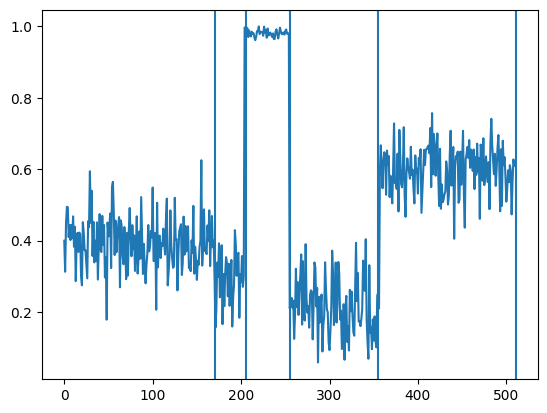

In [4]:
import matplotlib.pyplot as plt
import ruptures as rpt

def HighCPUDetect(cpu_percent, cp, margin=0,threshold=.8):
    """
    Implementa uma lógica de detecção de alta utilização da CPU.
    
    :param cpu_percent: vetor com a utilização da CPU em % (0-1)
    :param cp: vetor com os pontos de mudança (change points) detectados em cpu_percent, listados como índices correspondentes às suas posições. 
    Cosidera-se cada posição de cp como o último índice de um trecho (não deve conter 0).
    :param margin: número de índices a considerar para cada lado de cada trecho investigadona na aplicação do critério de detecção implementado.
    :param threshold: valor de limiar para considerar alta utilização da CPU
    
    :return segment: lista de trechos detectados, formatados como dicionários
    """
    segment=[]
    for cc, pos_up in enumerate(cp):
        pos_up=min(pos_up+margin,len(cpu_percent))
        pos_low=max(cp[cc-1]+1-margin,0) if cc>0 else 0
        
        
        avg=float(np.average(cpu_percent[pos_low:pos_up]))
        if avg>threshold: segment.append({'pos_low':pos_low,'pos_up':pos_up,'avg':avg})
    return segment

signal=df['CPU'].values

algo = rpt.Pelt(model="rbf").fit(signal)
result = algo.predict(pen=5)

segment = HighCPUDetect(signal,result,margin=0)

print(segment)
plt.plot(signal)
for r in result:
	plt.axvline(r)

C:\Users\leoki\AppData\Local\Temp\ipykernel_7860\980720404.py:32: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(ptc.Rectangle(xy=[Px,ymin],width=-MovingAverageWindow,height=5,


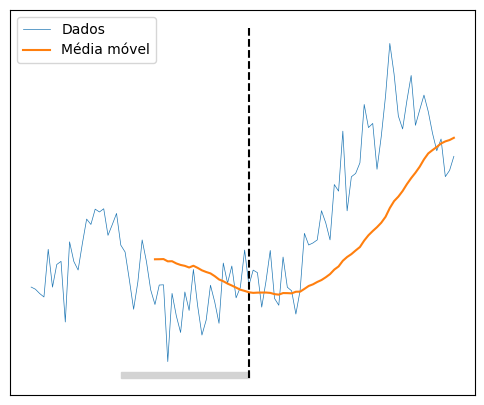

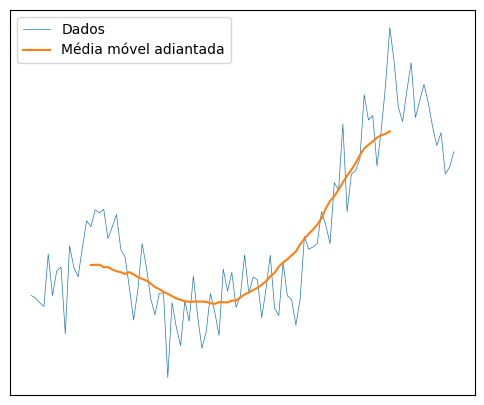

In [4]:
# Plota um gráfico ilustrativo do procedimento de cálculo do feature T_CPU_trend
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as ptc
import random
import math
Layer1Size=10
EscalaX=10
EscalaY=10
PreSmoothWindow=20
MovingAverageWindow=30

# Layer 1: Define a um vetor base manualmente. Dita a forma aproximada
x1=np.array(range(Layer1Size+2))*EscalaX
y1=np.array([0,0.08618527251172858,0.29276664037142175,0.17339907077578998,0.3148968679197107,0.2636046903087258,0.3962135971001429,0.4595127291716007,0.759708333177639,0.4605307631477288,0.5453521650684118,0.5453521650684118])
y1=y1+np.random.normal(scale=0.3,size=y1.shape)
y1=y1*EscalaY
x=np.array(range(max(x1)+1))
y=np.interp(x,x1,y1)
y=np.convolve(y, np.ones(PreSmoothWindow), mode='same')

# Layer 2: Acrescenta ruído de alta frequência
x=x[0:Layer1Size*EscalaX]
y=y[0:Layer1Size*EscalaX]
y=y+np.random.normal(scale=20,size=y.shape)

# Raw data
Px=math.floor(0.75*(max(x)-MovingAverageWindow))
fig, ax = plt.subplots(1,1,figsize=(6,5))
ax.plot(x,y,lw=0.5,label='Dados')
ymin, ymax = np.array(ax.get_ylim())
ax.add_patch(ptc.Rectangle(xy=[Px,ymin],width=-MovingAverageWindow,height=5,
                           color='lightgray',edgecolor='black',lw=1))
ax.plot([Px,Px],[ymin, ymax],ls='--',color='black')

# Moving average
MA=np.convolve(y, np.ones(MovingAverageWindow)/MovingAverageWindow, mode='valid')
ax.plot(x[MovingAverageWindow-1:x.size],MA,label='Média móvel')
ax.legend()
ax.set_xticks([])
ax.set_yticks([])
fig.savefig("MovingAverageA.svg",bbox_inches='tight')

fig, ax = plt.subplots(1,1,figsize=(6,5))
offset=math.floor(MovingAverageWindow/2)
ax.plot(x,y,lw=0.5,label='Dados')
ax.plot(x[MovingAverageWindow-1-offset:x.size-offset],MA,label='Média móvel adiantada')
ax.legend()
ax.set_xticks([])
ax.set_yticks([])

fig.savefig("MovingAverageB.svg",bbox_inches='tight')


C:\Users\leoki\AppData\Local\Temp\ipykernel_18908\1681588458.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=18)
C:\Users\leoki\AppData\Local\Temp\ipykernel_18908\1681588458.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=18)


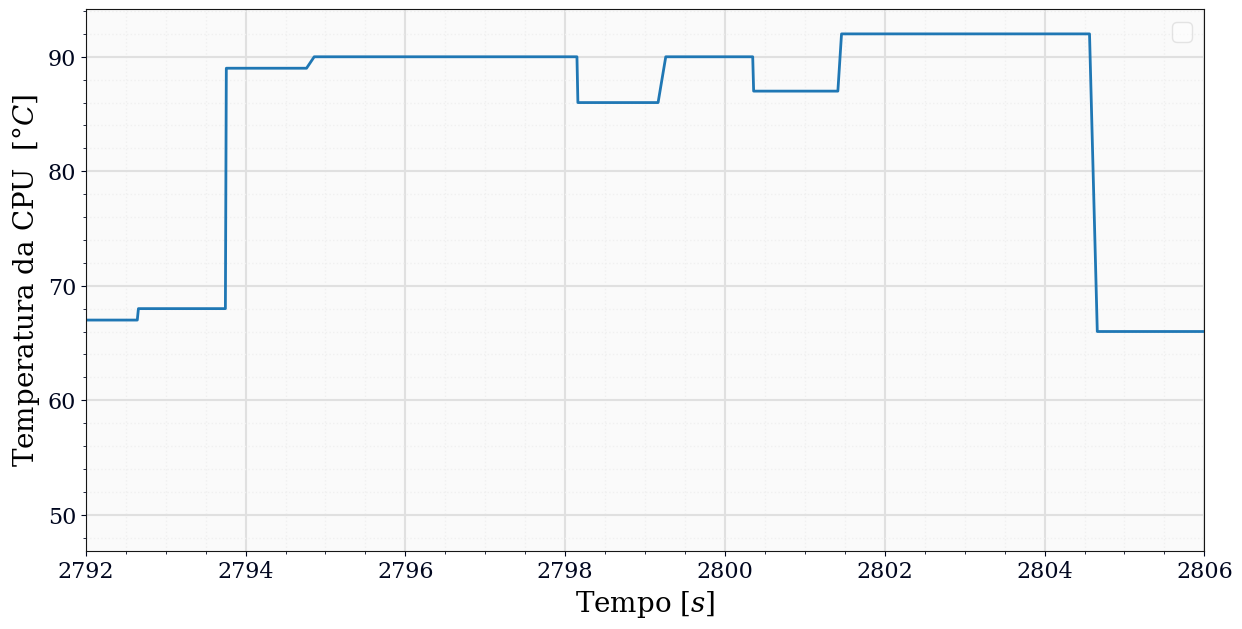

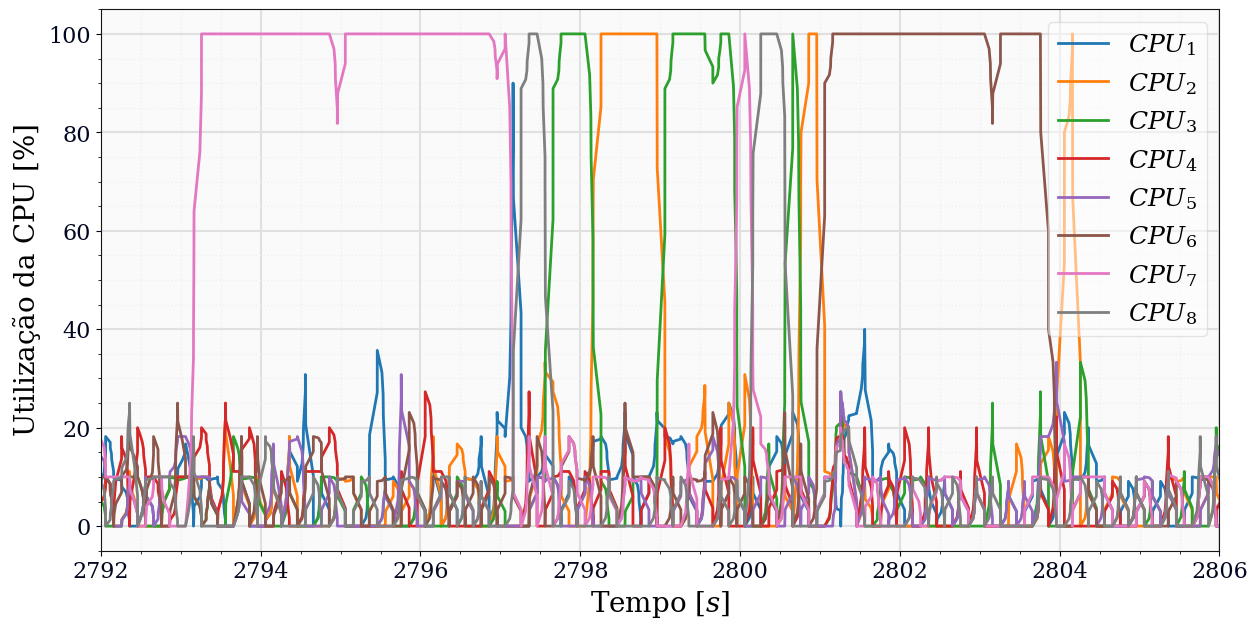

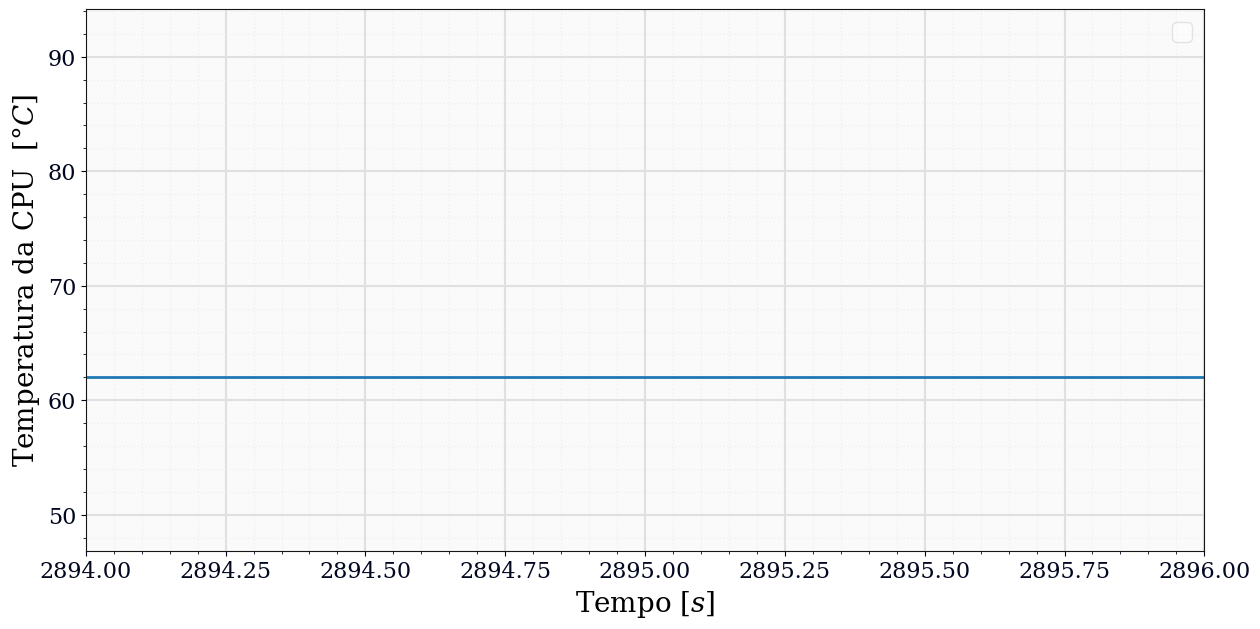

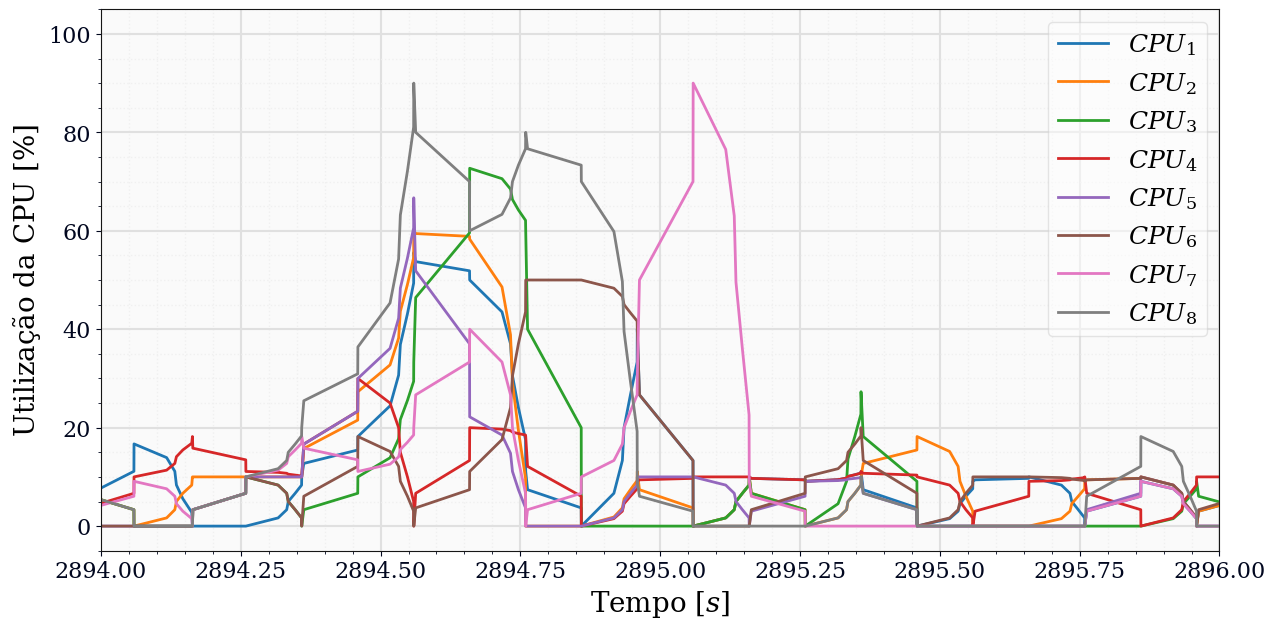

In [86]:
# Plota gráficos com zoom em instantes de interesse da telemetria
x=[2792,2806]	# Zoom no pico de temperatura

fig, ax = bagpy.create_fig(1)
ax=ax[0]
ax.plot('T_CPU',     data = telemetria,      label = '',       linewidth=2)
ax.set_xlim(x)
ax.set_ylabel('Temperatura da CPU  '+r'$[°C]$')
ax.legend(fontsize=18)
ax.set_xlabel('Tempo '+r'$[s]$')
ax.set_facecolor('#fafafa')
ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
ax.grid(which='minor', color='#f0f0f0', linewidth=1)
fig.savefig("TelemetryZoomTemperature1.svg", format='svg')

fig, ax = bagpy.create_fig(1)
ax=ax[0]
for CPU in range(NumCPUs):
	# kw = dict(linewidth=0.8) if CPU == 0 else dict(alpha=0.6, linewidth=0, linestyle=None, marker='o', markersize=1)
	kw=dict(linewidth=2)
	ax.plot(f'CPU_{CPU}', data = telemetria, label = fr'$CPU_{{{CPU+1}}}$', **kw)
ax.set_xlim(x)
ax.set_ylabel('Utilização da CPU '+r'$[\%]$')
ax.legend(fontsize=18,markerscale=5)
ax.set_xlabel('Tempo '+r'$[s]$')
ax.set_facecolor('#fafafa')
ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
ax.grid(which='minor', color='#f0f0f0', linewidth=1)
fig.savefig("TelemetryZoomCPU1.svg", format='svg')


x=[2894,2896]

fig, ax = bagpy.create_fig(1)
ax=ax[0]
ax.plot('T_CPU',     data = telemetria,      label = '',       linewidth=2)
ax.set_xlim(x)
ax.set_ylabel('Temperatura da CPU  '+r'$[°C]$')
ax.legend(fontsize=18)
ax.set_xlabel('Tempo '+r'$[s]$')
ax.set_facecolor('#fafafa')
ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
ax.grid(which='minor', color='#f0f0f0', linewidth=1)
fig.savefig("TelemetryZoomTemperature2.svg", format='svg')

fig, ax = bagpy.create_fig(1)
ax=ax[0]
for CPU in range(NumCPUs):
	# kw = dict(linewidth=0.8) if CPU == 0 else dict(alpha=0.6, linewidth=0, linestyle=None, marker='o', markersize=1)
	kw=dict(linewidth=2)
	ax.plot(f'CPU_{CPU}', data = telemetria, label = fr'$CPU_{{{CPU+1}}}$', **kw)
ax.set_xlim(x)
ax.set_ylabel('Utilização da CPU '+r'$[\%]$')
ax.legend(fontsize=18,markerscale=5)
ax.set_xlabel('Tempo '+r'$[s]$')
ax.set_facecolor('#fafafa')
ax.grid(which='major', color='#e0e0e0', linewidth=1.5)
ax.grid(which='minor', color='#f0f0f0', linewidth=1)
fig.savefig("TelemetryZoomCPU2.svg", format='svg')


<Axes: xlabel='Time'>

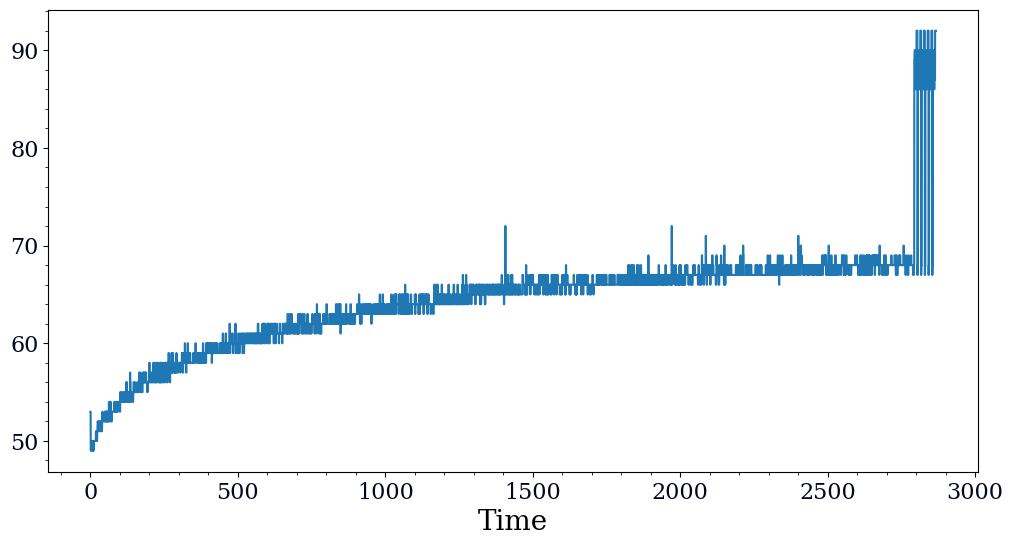

In [ ]:
# Copia o pico de temperatura e o trecho de CPU correspondente, e repete NumCopias vezes
NumCopias=5
def closestn(array,num,n):
    if isinstance(array,pd.Series): array = array.to_numpy()
    if isinstance(array[0],float): delta = np.ones(n, dtype=float) * np.finfo(float).max
    elif isinstance(array[0],int): delta = np.ones(n, dtype=int) * np.iinfo(int).max
    else: raise Exception('Data type not supported')
    
    NumElem=len(array)
    
    ind=[0]*n
    for i in range(NumElem):
        aux=abs(array[i]-num)
        for r in range(n):
            if delta[r]>aux: 
                for k in range(r,n-1):
                    delta[-k-1]=delta[-k-2]
                    ind[-k-1]=ind[-k-2]
                delta[r]=aux
                ind[r]=i
                break
    z=sorted(zip(array[ind]+0.0,ind,delta))
    y,x,delta=zip(*z)
    if isinstance(array[0], float):
        y = list(map(float, y))  # Convert y elements back to float
        delta = list(map(float, delta))  # Convert y elements back to float
    elif isinstance(array[0], int):
        y = list(map(int, y))  # Convert y elements back to float
        delta = list(map(int, delta))  # Convert y elements back to float
    return list(x),y,delta
closestn(df.index,2804.659727,1)
UltimaTempAlta=closestn(df.index,2804.659727,1)[0][0]-1
aux=df.iloc[0:UltimaTempAlta]
i_copy=closestn(aux.index,2792,1)[0][0]-1
copy=aux.iloc[i_copy:len(aux)]
shift_time=copy.index[-1]-copy.index[0]
for i in range(NumCopias):
    copy.index=copy.index+shift_time
    aux = pd.concat([aux, copy], axis=0, ignore_index=False)
aux['T_CPU'].plot()

In [9]:
import ddslib

# Criando o DataFrame com os dados sintéticos
Pt   = [0 ,     10,     12,     15,     21,     30  ]       # Tempos dos pontos definidos
Pcpu = [0.4,    0.3,    0.98,   0.21,   0.61,   0.61]       # %CPU dos pontos definidos

df=ddslib.SynthCPUpercent(Pt,Pcpu)
ChangePoints, Segments = ddslib.HighCPUDetect(df)

print('\n'.join(str(d) for d in Segments))

def FuncA(self, bagfile):
	return 
kernel = type("TP_type", (ddslib.FunctionWrapper,), {"__call__": FuncA})('MAC_aguas_claras_2025-01-21-12-07-24_0.bag')

M2=ddslib.M2(df, df, kernel, kernel, kernel)

{'state': 'norm', 'pos_low': 0, 'pos_up': 205, 'avg': 0.38784046333296707}
{'state': 'high', 'pos_low': 206, 'pos_up': 255, 'avg': 0.980474297298123}
{'state': 'norm', 'pos_low': 256, 'pos_up': 355, 'avg': 0.20350572281315898}
{'state': 'norm', 'pos_low': 356, 'pos_up': 511, 'avg': 0.6028650506049963}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Modelo de primeira ordem não homogêneo:
# T_{n+1} = A * T_n + B

# Parâmetros
tau_cpu = 5.0
tau_temp = 10.0
KCPU = 2.0
KTemp = 1.5
Text = 0.0
T0 = 10.0
FCPU = lambda cpu: cpu  # função de transferência para CPU
cpu_value = 1.0

# Passo de tempo
dt = 0.1
t = np.arange(0, 50 + dt, dt)
n_steps = len(t)

# Coeficientes discretos
beta_cpu = 1 - np.exp(-dt / tau_cpu)
beta_temp = 1 - np.exp(-dt / tau_temp)

A = 1 - KTemp * beta_temp
B = KTemp * beta_temp * Text + KCPU * beta_cpu * FCPU(cpu_value)

# Solução incremental (recorrência)
T_incr = np.zeros(n_steps)
T_incr[0] = T0
for i in range(n_steps - 1):
    T_incr[i+1] = A * T_incr[i] + B

# Solução fechada da recorrência
# T[n] = A^n * T0 + B * (1 - A^n) / (1 - A)
A_n = A ** np.arange(n_steps)
T_closed = A_n * T0 + B * (1 - A_n) / (1 - A)

# Plot para comparar
plt.figure()
plt.plot(t, T_incr, label='Incremental (recorrência)')
plt.plot(t, T_closed, linestyle='--', label='Fechada da recorrência')
plt.xlabel('Tempo')
plt.ylabel('Temperatura')
plt.legend()
plt.show()


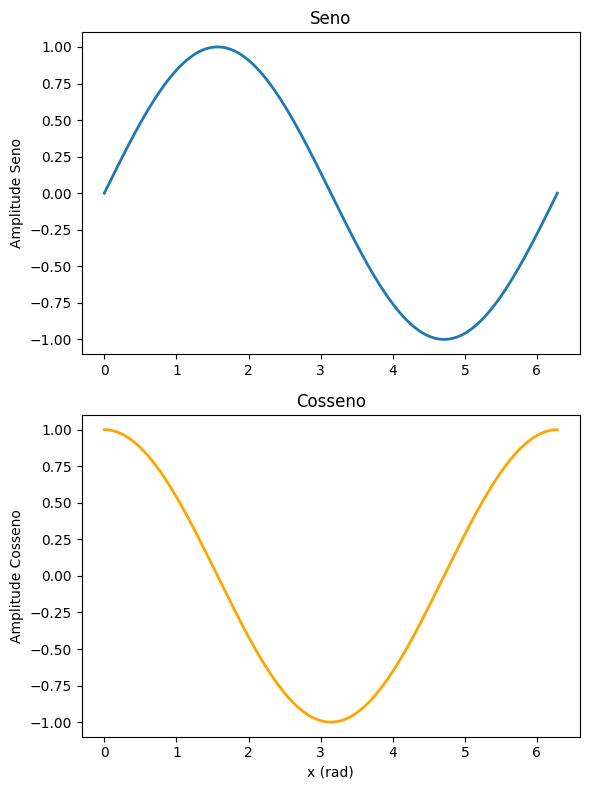

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1) Dados de exemplo
x = np.linspace(0, 2*np.pi, 200)
y1 = np.sin(x)
y2 = np.cos(x)

# 2) Cria figura com dois subplots verticais
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

# 3) Desenha algo em cada um
ax1.plot(x, y1, lw=2)
ax1.set_title('Seno')
ax1.set_ylabel('Amplitude Seno')

ax2.plot(x, y2, c='orange', lw=2)
ax2.set_title('Cosseno')
ax2.set_ylabel('Amplitude Cosseno')
ax2.set_xlabel('x (rad)')

plt.tight_layout()  # organiza melhor os espaços

# 4) Salvar a figura completa (todo mundo junto)
fig.savefig('todos_juntos.png', dpi=150)

# 5) Agora, para salvar somente o subplot 1:
renderer = fig.canvas.get_renderer()
bbox1 = ax1.get_tightbbox(renderer)                  # retângulo em pixels
extent1 = bbox1.transformed(fig.dpi_scale_trans.inverted())  # converte em polegadas
fig.savefig('subplot1_seno.png', bbox_inches=extent1, dpi=150)

# 6) E para salvar somente o subplot 2:
bbox2 = ax2.get_tightbbox(renderer)
extent2 = bbox2.transformed(fig.dpi_scale_trans.inverted())
fig.savefig('subplot2_cosseno.png', bbox_inches=extent2, dpi=150)

plt.show()


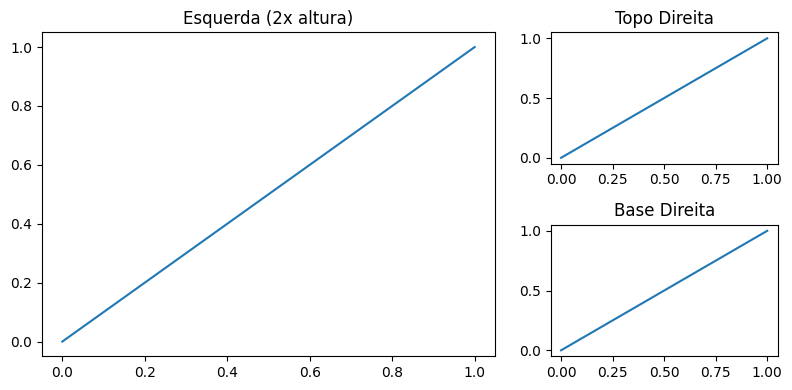

In [2]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 4))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 1])

ax_left = fig.add_subplot(gs[:, 0])
ax_topright = fig.add_subplot(gs[0, 1])
ax_bottomright = fig.add_subplot(gs[1, 1])

ax_left.set_title("Esquerda (2x altura)")
ax_topright.set_title("Topo Direita")
ax_bottomright.set_title("Base Direita")

for ax in [ax_left, ax_topright, ax_bottomright]:
	ax.plot([0, 1], [0, 1])

plt.tight_layout()
plt.show()


In [9]:
import numpy as np

a = [[1, 2, 3], [4, 5], [6, 7]]
b = [11,12,13]
c = np.concatenate(a).tolist()
np.concatenate(a+[b]).tolist()


[1, 2, 3, 4, 5, 6, 7, 11, 12, 13]